# DC Housing Market Analysis: Exploratory Data Analysis

This notebook conducts a comprehensive exploratory data analysis of the DC housing market and related economic indicators. We'll examine statistical properties, trends, correlations, and patterns to gain insights into the dynamics of the housing market.

In [83]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from datetime import datetime
import os
import json
from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Set visualization styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

# Create directories for saving visualizations
os.makedirs('outputs/EDA', exist_ok=True)
print("Output directory set to: outputs/EDA")

Output directory set to: outputs/EDA


## 1. Data Loading and Initial Examination

We begin by loading our processed dataset from the `01_data_processing.ipynb` notebook. This dataset contains monthly economic indicators for Washington DC, including housing prices, unemployment rates, interest rates, and demographic information.

In [66]:
# Load the processed dataset from root directory
df = pd.read_csv('dc_economic_monthly_dataframe.csv')

# Convert Date column to datetime and set as index for time series analysis
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

# Display basic information
print(f"Dataset dimensions: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Time period: {df.index.min().strftime('%B %Y')} to {df.index.max().strftime('%B %Y')}")
print(f"Duration: {((df.index.max() - df.index.min()).days / 365.25):.1f} years")
print("\nColumns in dataset:")
for col in df.columns:
    print(f"- {col}")

# Check for missing values
missing = df.isnull().sum()
if missing.sum() > 0:
    print("\nMissing values found in:")
    print(missing[missing > 0])
else:
    print("\nNo missing values in the dataset")

# Display the first few rows to verify data structure
df.head()

Dataset dimensions: 300 rows × 13 columns
Time period: January 2000 to December 2024
Duration: 24.9 years

Columns in dataset:
- Year
- Month
- Unemployment_Rate
- CPI
- Interest_Rate
- Mortgage_Rate
- ZHVI
- GDP_Growth
- Median_Household_Income
- Population
- Poverty_Rate
- Marriage_Rate
- Divorce_Rate

No missing values in the dataset


,Year,Month,Unemployment_Rate,CPI,Interest_Rate,Mortgage_Rate,ZHVI,GDP_Growth,Median_Household_Income,Population,Poverty_Rate,Marriage_Rate,Divorce_Rate
Date,,,,,,,,,,,,,
2000-01-01,2000,1,5.70,169.80,5.45,8.21,179200.93,1.50,41220.00,572.05,17.50,3.92,3.36
2000-02-01,2000,2,5.70,171.50,5.73,8.32,179346.63,1.50,41771.03,572.05,17.50,3.92,3.20
2000-03-01,2000,3,5.70,173.20,5.85,8.24,179615.18,6.89,42158.65,572.05,17.50,4.41,3.20
2000-04-01,2000,4,5.60,172.85,6.02,8.15,180223.23,8.59,42447.39,572.05,17.50,4.90,3.04
2000-05-01,2000,5,5.60,172.50,6.27,8.52,181147.58,7.50,42614.02,572.05,17.50,5.39,3.04


## 2. Descriptive Statistics

Let's examine the statistical properties of our variables to understand their distributions, central tendencies, and spread. This provides a foundation for our analysis.

Enhanced Descriptive Statistics:


,count,mean,std,min,10%,25%,50%,75%,90%,max,range,coef_var,skewness,kurtosis
Year,300.00,2012.00,7.22,2000.00,2002.00,2006.00,2012.00,2018.00,2022.00,2024.00,24.00,0.36,0.00,-1.20
Month,300.00,6.50,3.46,1.00,2.00,3.75,6.50,9.25,11.00,12.00,11.00,53.20,0.00,-1.22
Unemployment_Rate,300.00,7.04,1.58,4.00,5.30,5.90,6.70,8.10,9.71,11.20,7.20,22.48,0.65,-0.37
CPI,300.00,238.06,38.29,169.80,184.17,207.41,242.39,262.03,298.34,317.38,147.58,16.09,0.13,-0.68
Interest_Rate,300.00,1.92,2.02,0.05,0.09,0.14,1.21,3.53,5.26,6.54,6.49,105.35,0.84,-0.74
Mortgage_Rate,300.00,5.15,1.39,2.68,3.46,3.95,4.99,6.28,6.92,8.52,5.83,27.05,0.21,-0.98
ZHVI,300.00,373171.07,95902.56,179200.93,231788.45,316304.08,372792.13,425195.24,527521.82,568278.85,389077.92,25.70,0.02,-0.36
GDP_Growth,300.00,2.30,4.65,-29.10,-0.41,1.40,2.47,3.46,4.72,35.20,64.30,202.71,-0.01,27.87
Median_Household_Income,300.00,68180.48,22535.55,38742.59,42678.40,48899.84,62284.26,87885.23,106495.24,111000.00,72257.41,33.05,0.55,-0.95
Population,300.00,631.91,52.85,567.14,568.50,574.40,635.74,677.01,702.25,708.25,141.12,8.36,0.02,-1.68


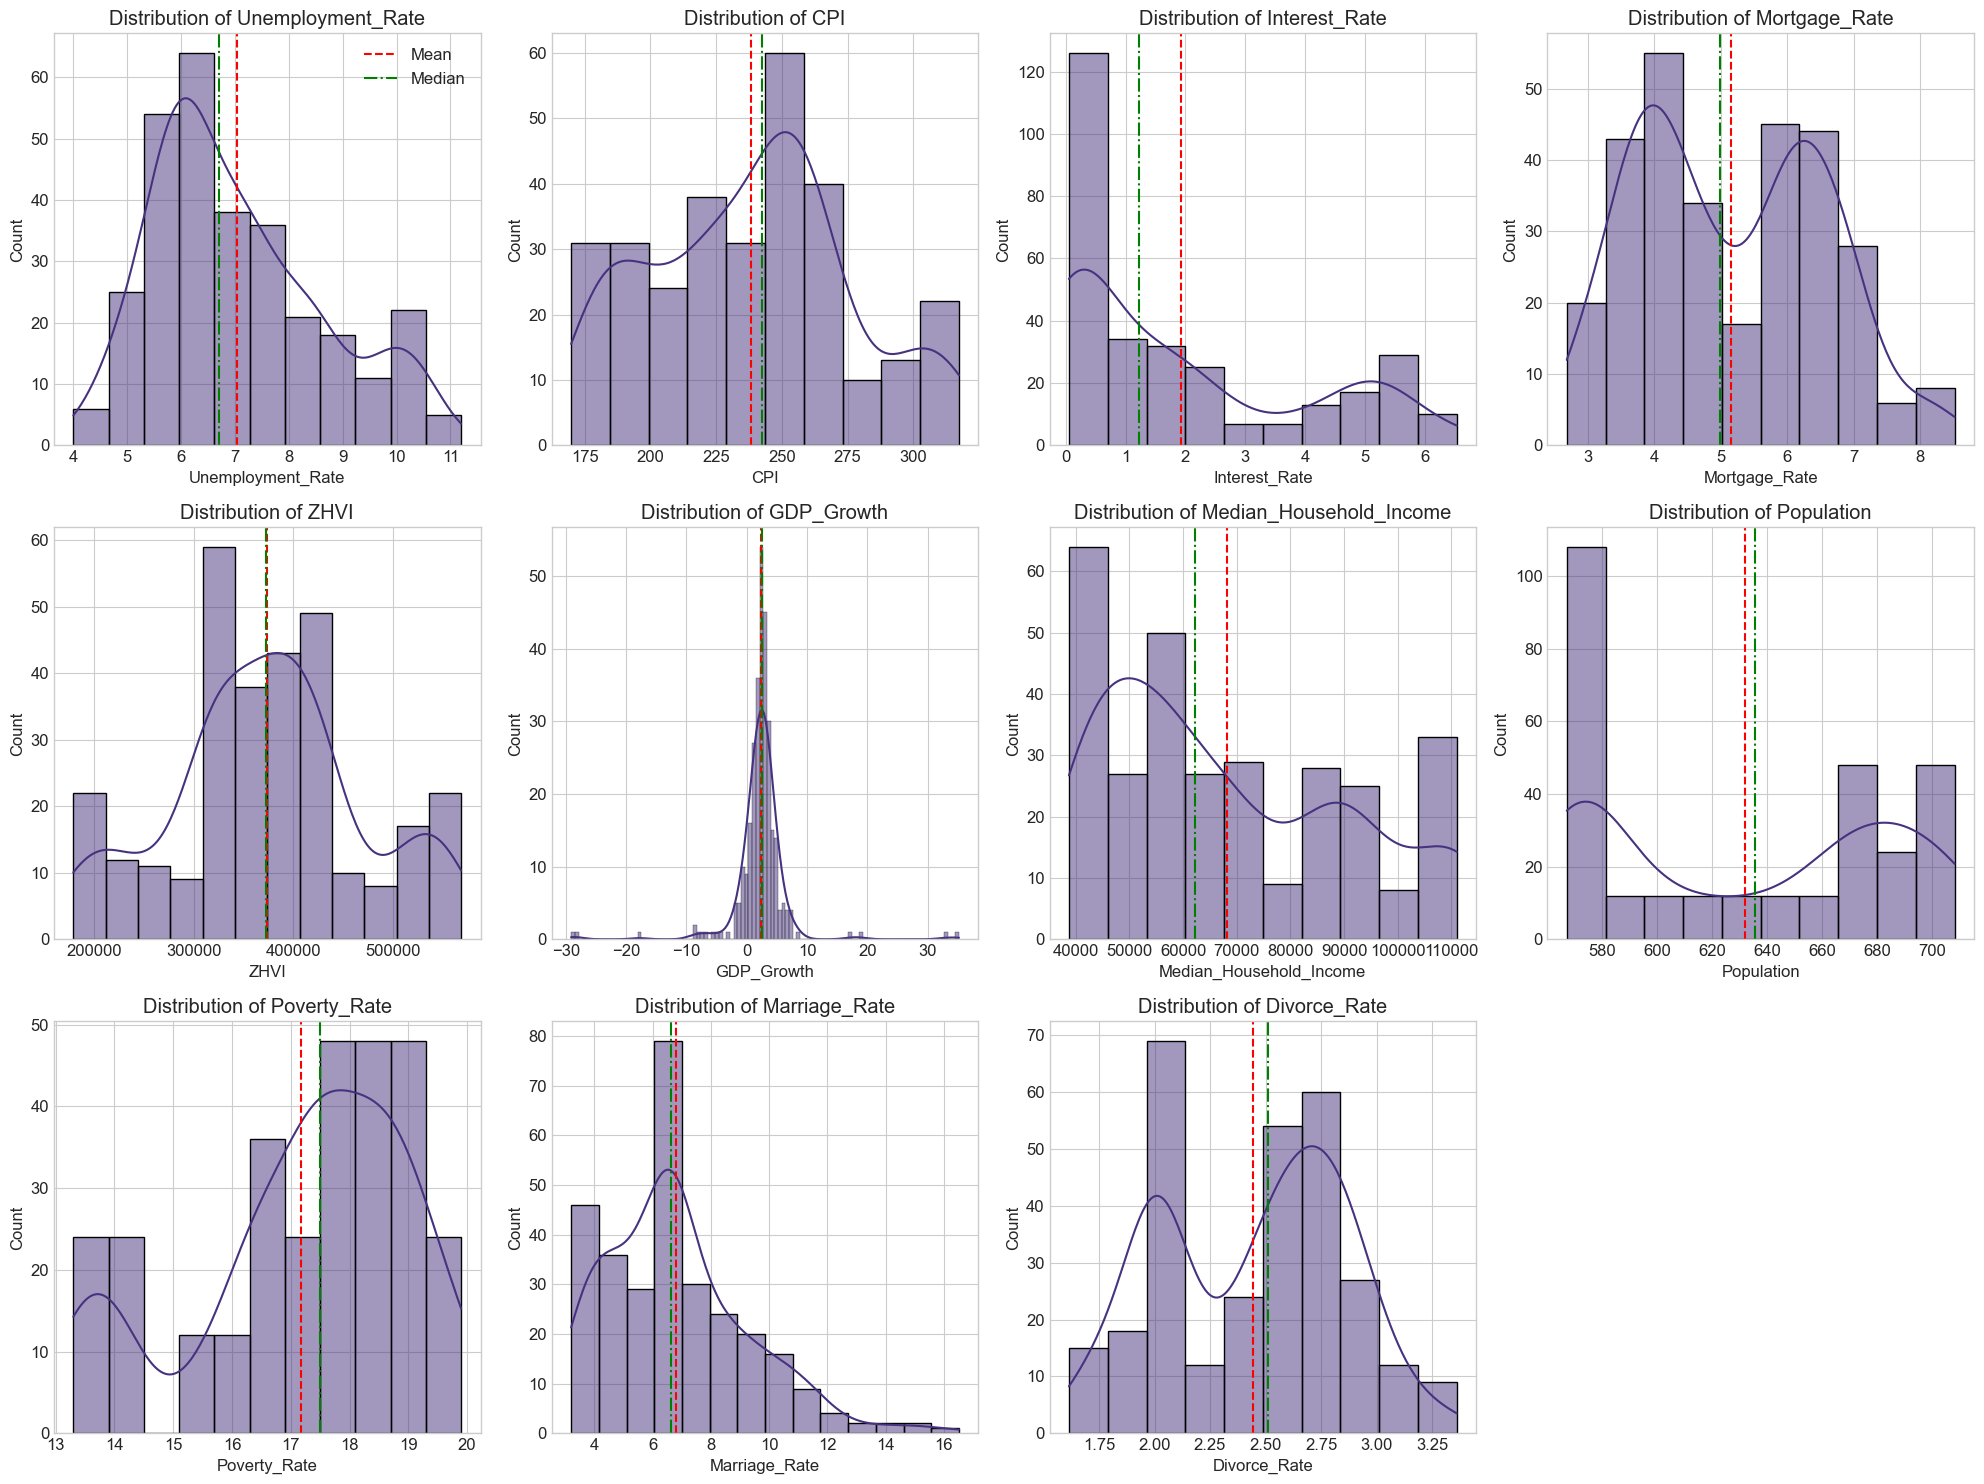

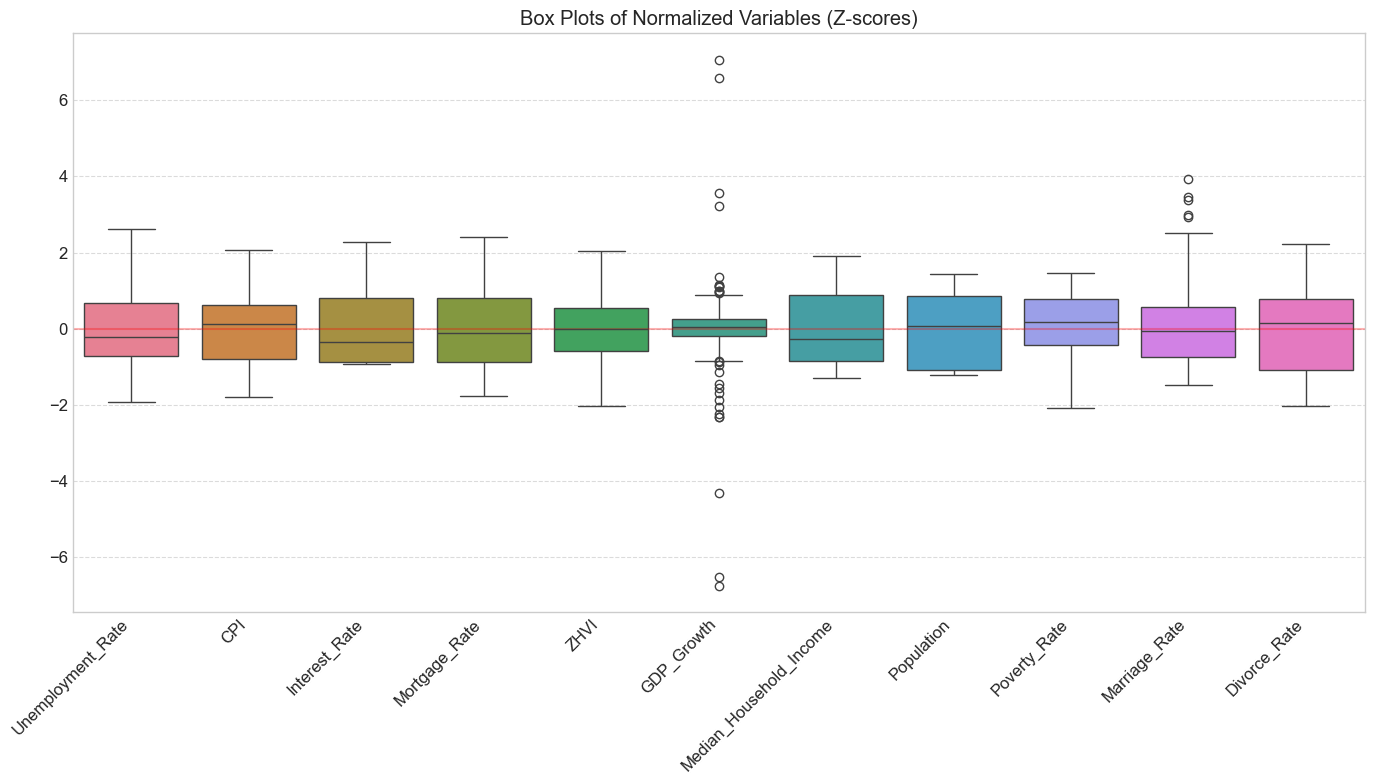


=== Key Observations from Descriptive Statistics ===

1. Central Tendencies:
  - Unemployment_Rate: Mean = 7.04, Median = 6.70, Skewness = 0.65 (right skew)
  - CPI: Mean = 238.06, Median = 242.39, Skewness = 0.13 (minimal skew)
  - Interest_Rate: Mean = 1.92, Median = 1.21, Skewness = 0.84 (right skew)
  - Mortgage_Rate: Mean = 5.15, Median = 4.99, Skewness = 0.21 (minimal skew)
  - ZHVI: Mean = 373171.07, Median = 372792.13, Skewness = 0.02 (minimal skew)
  - GDP_Growth: Mean = 2.30, Median = 2.47, Skewness = -0.01 (minimal skew)
  - Median_Household_Income: Mean = 68180.48, Median = 62284.26, Skewness = 0.55 (right skew)
  - Population: Mean = 631.91, Median = 635.74, Skewness = 0.02 (minimal skew)
  - Poverty_Rate: Mean = 17.17, Median = 17.50, Skewness = -0.72 (left skew)
  - Marriage_Rate: Mean = 6.82, Median = 6.64, Skewness = 0.91 (right skew)
  - Divorce_Rate: Mean = 2.44, Median = 2.51, Skewness = -0.12 (minimal skew)

2. Variability:
  - Unemployment_Rate: Coefficient of Va

In [67]:
# Generate comprehensive descriptive statistics
desc_stats = df.describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]).T

# Add additional statistics
desc_stats['range'] = desc_stats['max'] - desc_stats['min']
desc_stats['coef_var'] = desc_stats['std'] / desc_stats['mean'] * 100  # Coefficient of variation
desc_stats['skewness'] = df.skew()
desc_stats['kurtosis'] = df.kurtosis()

# Display the enhanced statistics
print("Enhanced Descriptive Statistics:")
desc_stats = desc_stats[['count', 'mean', 'std', 'min', '10%', '25%', '50%', '75%', '90%', 'max', 'range', 'coef_var', 'skewness', 'kurtosis']]
display(desc_stats)

# Create visualizations of distributions
fig, axs = plt.subplots(3, 4, figsize=(20, 15))
axs = axs.flatten()

for i, col in enumerate(df.drop(['Year', 'Month'], axis=1).columns):
    if i < len(axs):
        # Create a density plot with histogram
        sns.histplot(df[col], kde=True, ax=axs[i])
        axs[i].set_title(f'Distribution of {col}')
        
        # Add mean and median lines
        axs[i].axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
        axs[i].axvline(df[col].median(), color='green', linestyle='-.', label='Median')
        
        # Add labels
        if i == 0:  # Only add legend to the first plot
            axs[i].legend()
            
        # Format x-axis to avoid scientific notation
        axs[i].ticklabel_format(axis='x', style='plain')
        
# Hide any unused subplots
for j in range(i+1, len(axs)):
    axs[j].set_visible(False)
    
plt.tight_layout()
plt.savefig('outputs/EDA/variable_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# Create box plots to visualize the distribution and identify outliers
plt.figure(figsize=(14, 8))
columns_to_plot = [col for col in df.columns if col not in ['Year', 'Month']]

# Normalize data for better visual comparison
df_normalized = (df[columns_to_plot] - df[columns_to_plot].mean()) / df[columns_to_plot].std()
sns.boxplot(data=df_normalized)
plt.title('Box Plots of Normalized Variables (Z-scores)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)  # Add mean reference line
plt.tight_layout()
plt.savefig('outputs/EDA/normalized_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary of key observations from descriptive statistics
print("\n=== Key Observations from Descriptive Statistics ===")
print("\n1. Central Tendencies:")
for col in columns_to_plot:
    mean_val = df[col].mean()
    median_val = df[col].median()
    skew = df[col].skew()
    skew_direction = "right" if skew > 0.5 else "left" if skew < -0.5 else "minimal"
    print(f"  - {col}: Mean = {mean_val:.2f}, Median = {median_val:.2f}, Skewness = {skew:.2f} ({skew_direction} skew)")

print("\n2. Variability:")
for col in columns_to_plot:
    cv = (df[col].std() / df[col].mean()) * 100
    variability = "high" if cv > 30 else "moderate" if cv > 15 else "low"
    print(f"  - {col}: Coefficient of Variation = {cv:.2f}% ({variability} variability)")

## 3. Trend Analysis

Let's examine how each variable has evolved over time. This will help us identify key trends, cycles, and anomalies in the data, particularly in relation to the housing market.

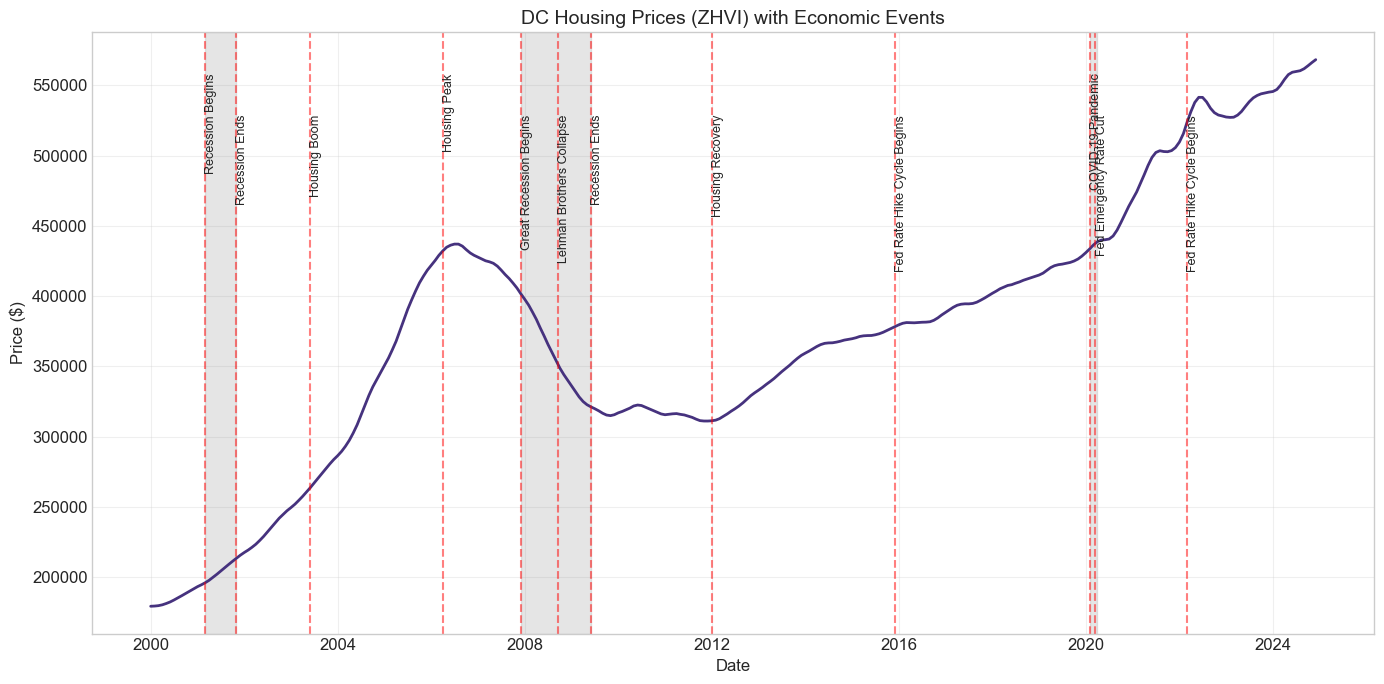

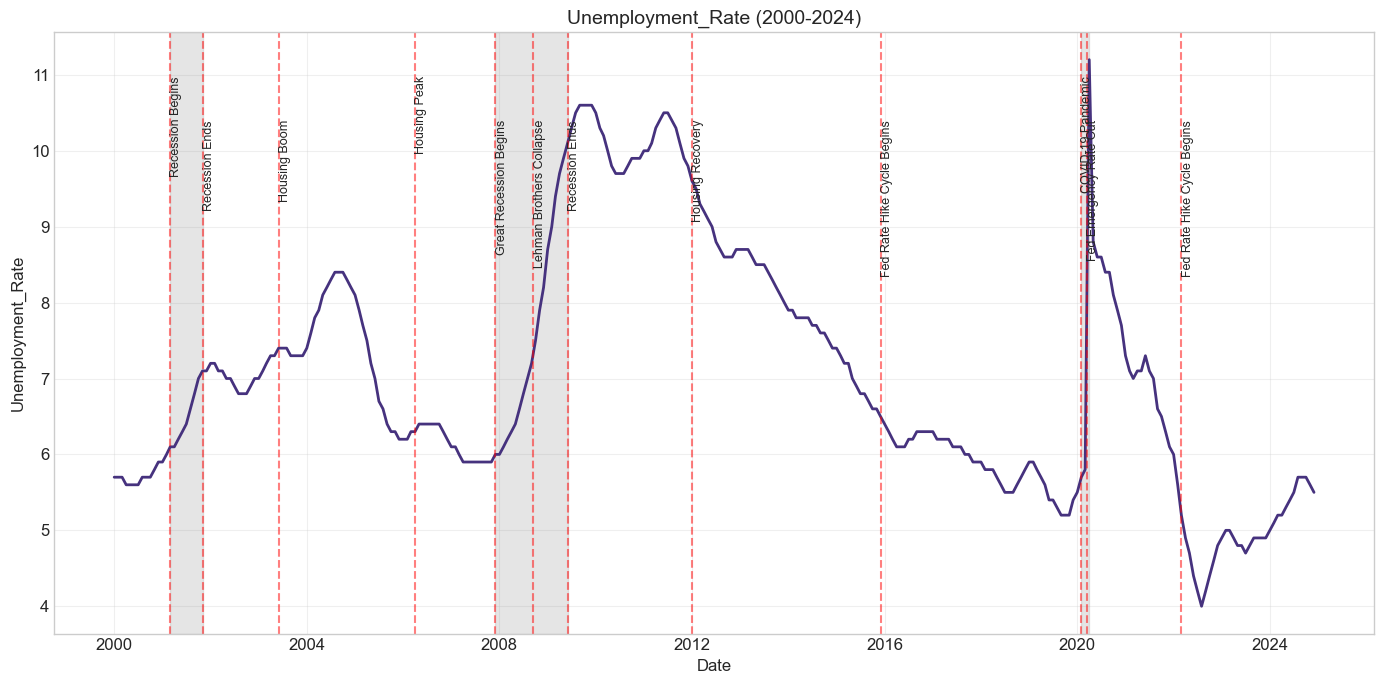

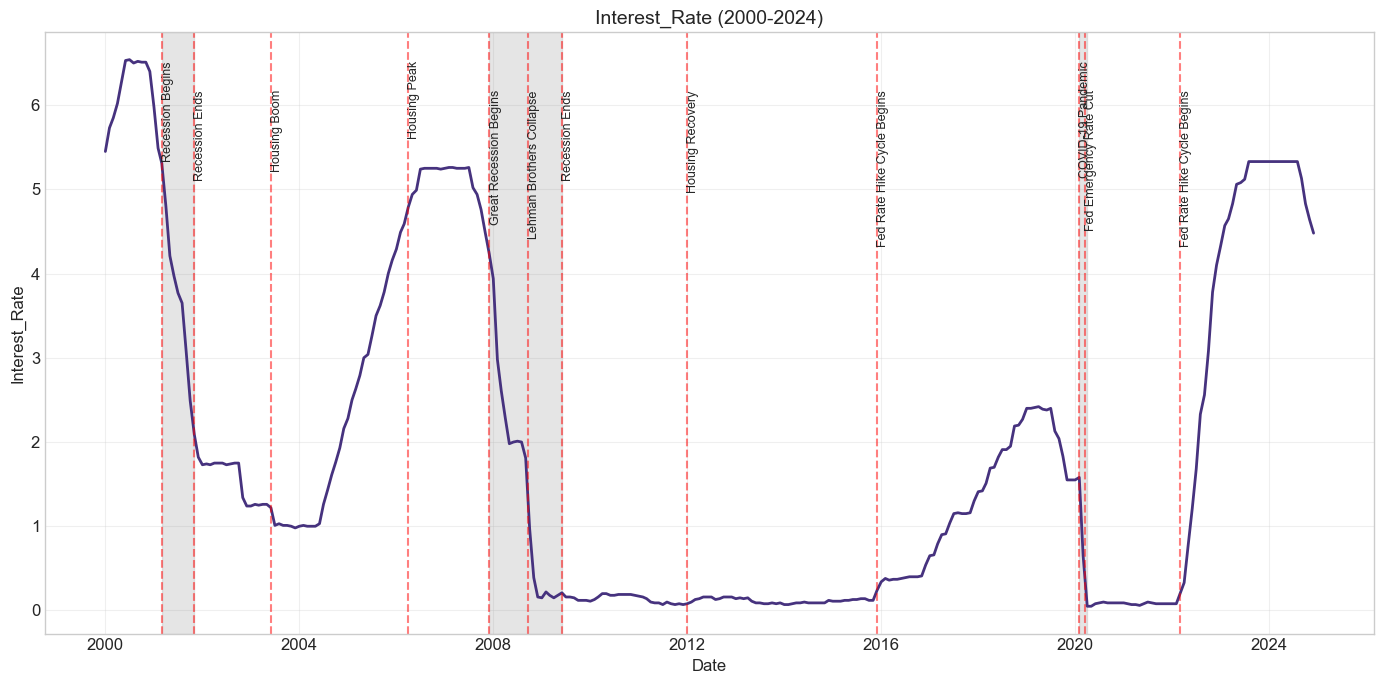

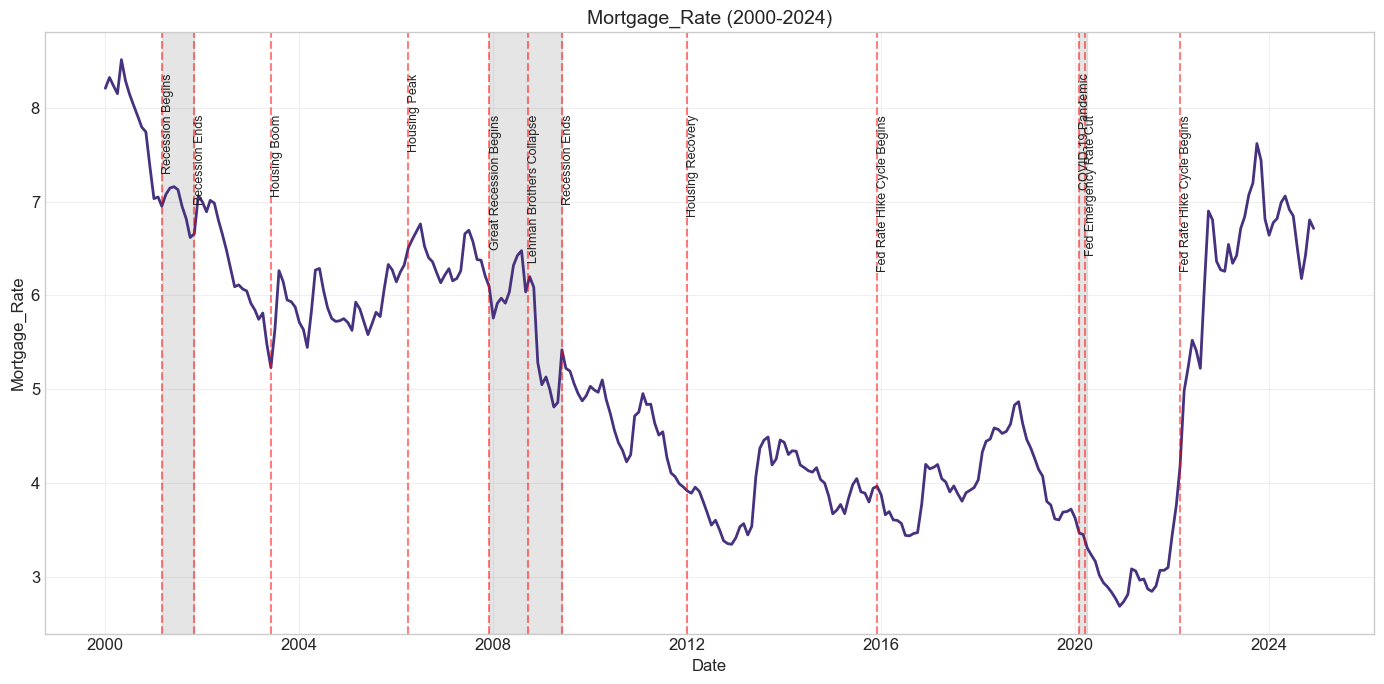

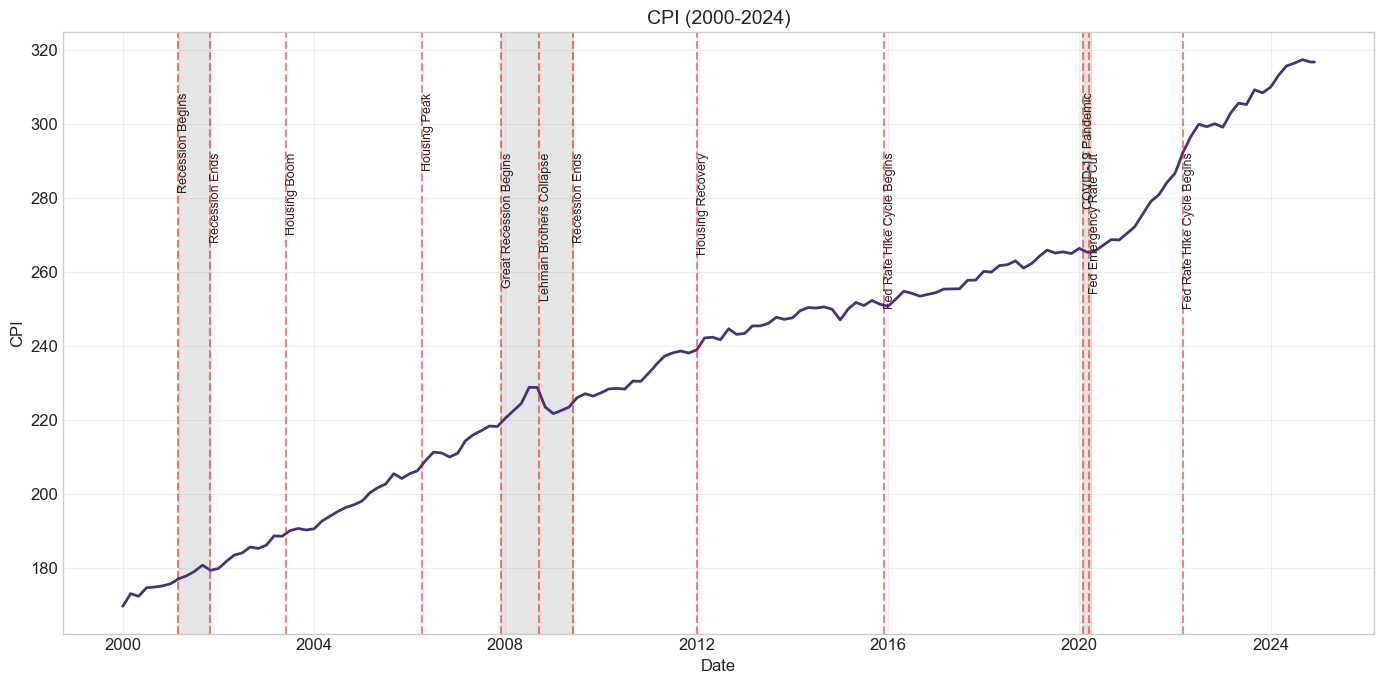

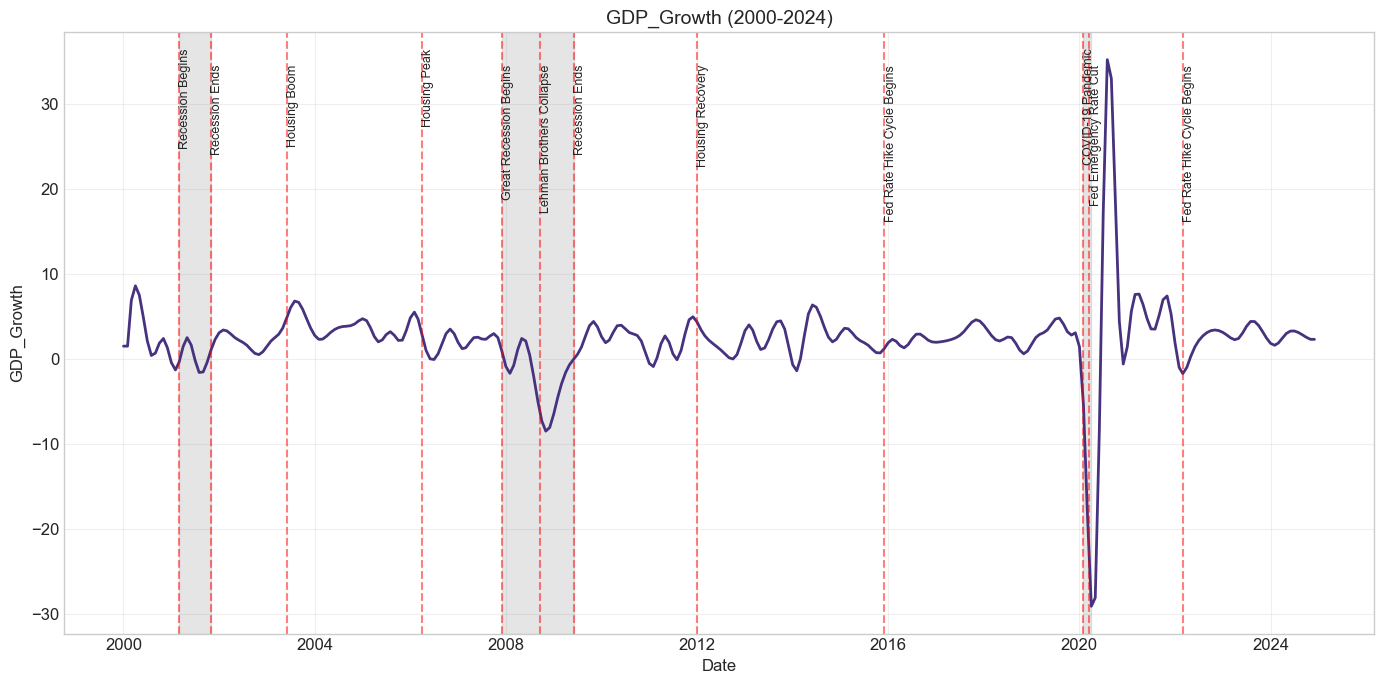

,Period,Start,End,Duration (Years),Total Change (%),Annualized Change (%),Avg. Interest Rate (%),Avg. Mortgage Rate (%),Avg. Unemployment (%)
0,Housing Boom,Jan 2000,Apr 2006,6.25,141.15,15.13,3.00,6.50,6.88
1,Housing Bust,May 2006,May 2009,3.00,-25.78,-9.46,3.40,6.08,6.79
2,Post-Crisis Stabilization,Jun 2009,Jan 2012,2.58,-3.09,-1.21,0.14,4.67,10.14
3,Recovery & Growth,Feb 2012,Dec 2019,7.83,37.45,4.15,0.74,3.97,6.92
4,Pandemic Boom,Jan 2020,Dec 2021,1.92,17.35,8.71,0.23,3.03,7.38
5,Rate Hike Era,Jan 2022,Jan 2024,2.00,7.06,3.47,3.43,6.08,4.82


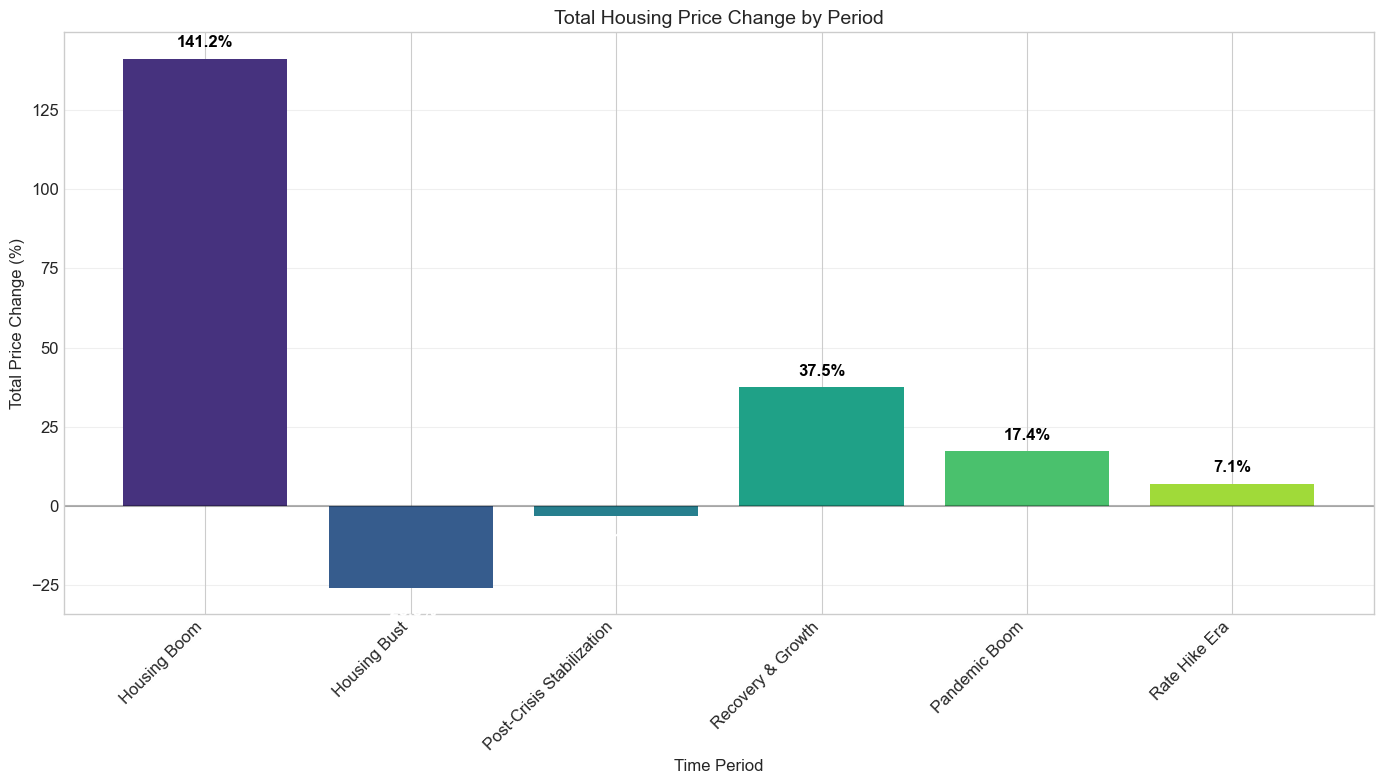

In [68]:
# Define important economic events for reference
economic_events = {
    '2001-03-01': 'Recession Begins',
    '2001-11-01': 'Recession Ends',
    '2003-06-01': 'Housing Boom',
    '2006-04-01': 'Housing Peak',
    '2007-12-01': 'Great Recession Begins',
    '2008-09-15': 'Lehman Brothers Collapse',
    '2009-06-01': 'Recession Ends',
    '2012-01-01': 'Housing Recovery',
    '2015-12-01': 'Fed Rate Hike Cycle Begins',
    '2020-02-01': 'COVID-19 Pandemic',
    '2020-03-15': 'Fed Emergency Rate Cut',
    '2022-03-01': 'Fed Rate Hike Cycle Begins'
}

# Function to plot time series with economic events
def plot_time_series(df, column, title=None, ylabel=None, show_events=True, label_events=True):
    """Plot a time series with economic events highlighted"""
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Plot the time series
    ax.plot(df.index, df[column], linewidth=2)
    
    # Add recession periods as shaded areas
    recessions = [
        ('2001-03-01', '2001-11-01'),  # Dot-com bubble
        ('2007-12-01', '2009-06-01'),  # Great Recession
        ('2020-02-01', '2020-04-01')   # COVID-19 Recession
    ]
    
    if show_events:
        for start, end in recessions:
            ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), alpha=0.2, color='gray')
        
        # Add vertical lines for key events
        for date, event in economic_events.items():
            date_obj = pd.to_datetime(date)
            if date_obj >= df.index.min() and date_obj <= df.index.max():
                ax.axvline(date_obj, color='r', linestyle='--', alpha=0.5)
                
                # Add labels if requested
                if label_events:
                    y_pos = 0.95 if event in ['Recession Begins', 'Housing Peak', 'COVID-19 Pandemic'] else 0.9
                    ax.text(date_obj, ax.get_ylim()[1] * y_pos, event, rotation=90, 
                            verticalalignment='top', fontsize=9)
    
    # Set title and labels
    ax.set_title(title or f"{column} (2000-2024)", fontsize=14)
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel(ylabel or column, fontsize=12)
    
    # Add grid
    ax.grid(True, alpha=0.3)
    
    # Format y-axis to avoid scientific notation
    ax.get_yaxis().get_major_formatter().set_scientific(False)
    
    # Adjust layout and save
    plt.tight_layout()
    plt.savefig(f'outputs/EDA/{column.lower()}_trend.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return fig, ax

# Plot ZHVI (Housing Prices) with economic events
plot_time_series(df, 'ZHVI', 'DC Housing Prices (ZHVI) with Economic Events', 'Price ($)')

# Plot key economic indicators
economic_indicators = ['Unemployment_Rate', 'Interest_Rate', 'Mortgage_Rate', 'CPI', 'GDP_Growth']
for indicator in economic_indicators:
    plot_time_series(df, indicator)

# Calculate and plot annual growth rates
df_pct_change = df.copy()
for col in df.columns:
    if col not in ['Year', 'Month']:
        df_pct_change[f'{col}_YoY_pct'] = df[col].pct_change(periods=12) * 100

# Identify key trend periods for housing prices
trend_periods = [
    ('2000-01-01', '2006-04-01', 'Housing Boom'),
    ('2006-05-01', '2009-05-01', 'Housing Bust'),
    ('2009-06-01', '2012-01-01', 'Post-Crisis Stabilization'),
    ('2012-02-01', '2019-12-01', 'Recovery & Growth'),
    ('2020-01-01', '2021-12-01', 'Pandemic Boom'),
    ('2022-01-01', '2024-01-01', 'Rate Hike Era')
]

# Calculate statistics for each period
period_stats = []
for start, end, name in trend_periods:
    period_df = df.loc[start:end]
    
    # Calculate total change and average annual change
    start_zhvi = period_df['ZHVI'].iloc[0]
    end_zhvi = period_df['ZHVI'].iloc[-1]
    total_chg = (end_zhvi - start_zhvi) / start_zhvi * 100
    
    # Calculate duration in years
    duration_years = (pd.to_datetime(end) - pd.to_datetime(start)).days / 365.25
    annual_chg = (((end_zhvi / start_zhvi) ** (1/duration_years)) - 1) * 100
    
    period_stats.append({
        'Period': name,
        'Start': pd.to_datetime(start).strftime('%b %Y'),
        'End': pd.to_datetime(end).strftime('%b %Y'),
        'Duration (Years)': duration_years,
        'Start ZHVI': start_zhvi,
        'End ZHVI': end_zhvi,
        'Total Change (%)': total_chg,
        'Annualized Change (%)': annual_chg,
        'Avg. Interest Rate (%)': period_df['Interest_Rate'].mean(),
        'Avg. Mortgage Rate (%)': period_df['Mortgage_Rate'].mean(),
        'Avg. Unemployment (%)': period_df['Unemployment_Rate'].mean()
    })

# Convert to DataFrame for display
period_stats_df = pd.DataFrame(period_stats)
display(period_stats_df[['Period', 'Start', 'End', 'Duration (Years)', 'Total Change (%)', 'Annualized Change (%)', 
                          'Avg. Interest Rate (%)', 'Avg. Mortgage Rate (%)', 'Avg. Unemployment (%)']])

# Create a visualization of housing price changes by period
plt.figure(figsize=(14, 8))
plt.bar(period_stats_df['Period'], period_stats_df['Total Change (%)'], color=sns.color_palette("viridis", len(period_stats_df)))
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.title('Total Housing Price Change by Period', fontsize=14)
plt.xlabel('Time Period', fontsize=12)
plt.ylabel('Total Price Change (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add data labels
for i, value in enumerate(period_stats_df['Total Change (%)']):
    plt.text(i, value + (5 if value >= 0 else -5), f'{value:.1f}%', 
             ha='center', va='center' if value >= 0 else 'top', 
             fontweight='bold', color='black' if value >= 0 else 'white')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/EDA/zhvi_change_by_period.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Correlation Analysis

We'll analyze the relationships between different variables to understand how they interact and which factors have the strongest relationship with housing prices.

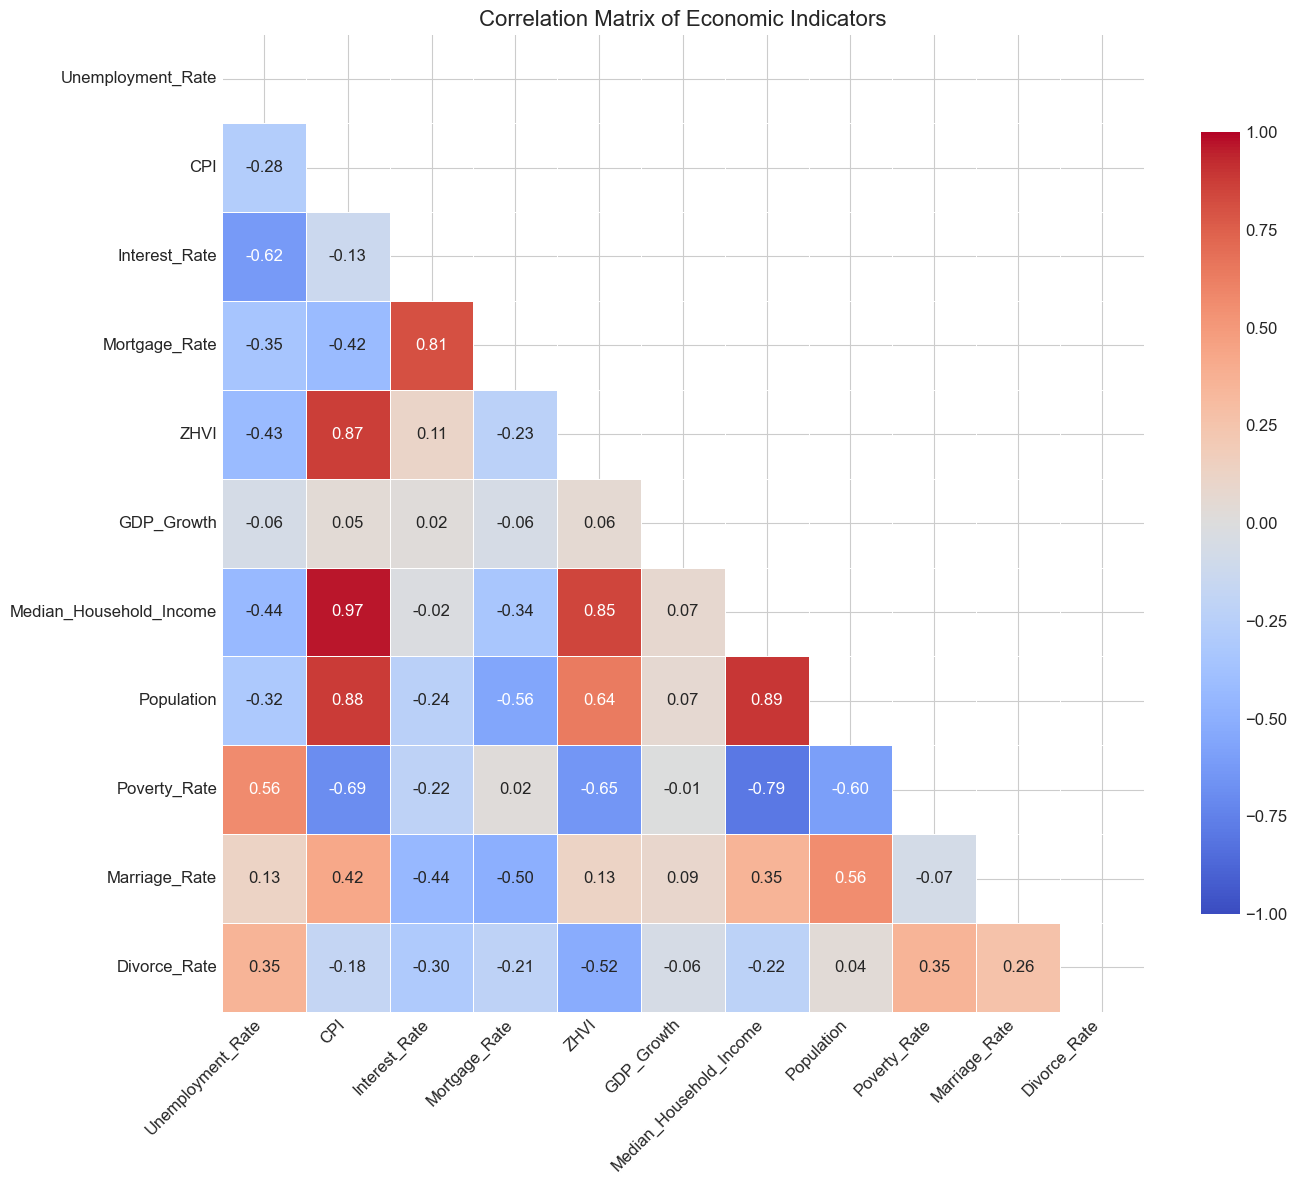

In [82]:
# Calculate correlation matrix
correlation_vars = [col for col in df.columns if col not in ['Year', 'Month']]
corr_matrix = df[correlation_vars].corr()

# Create correlation heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Create mask for upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, fmt='.2f',
            linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Economic Indicators', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/EDA/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

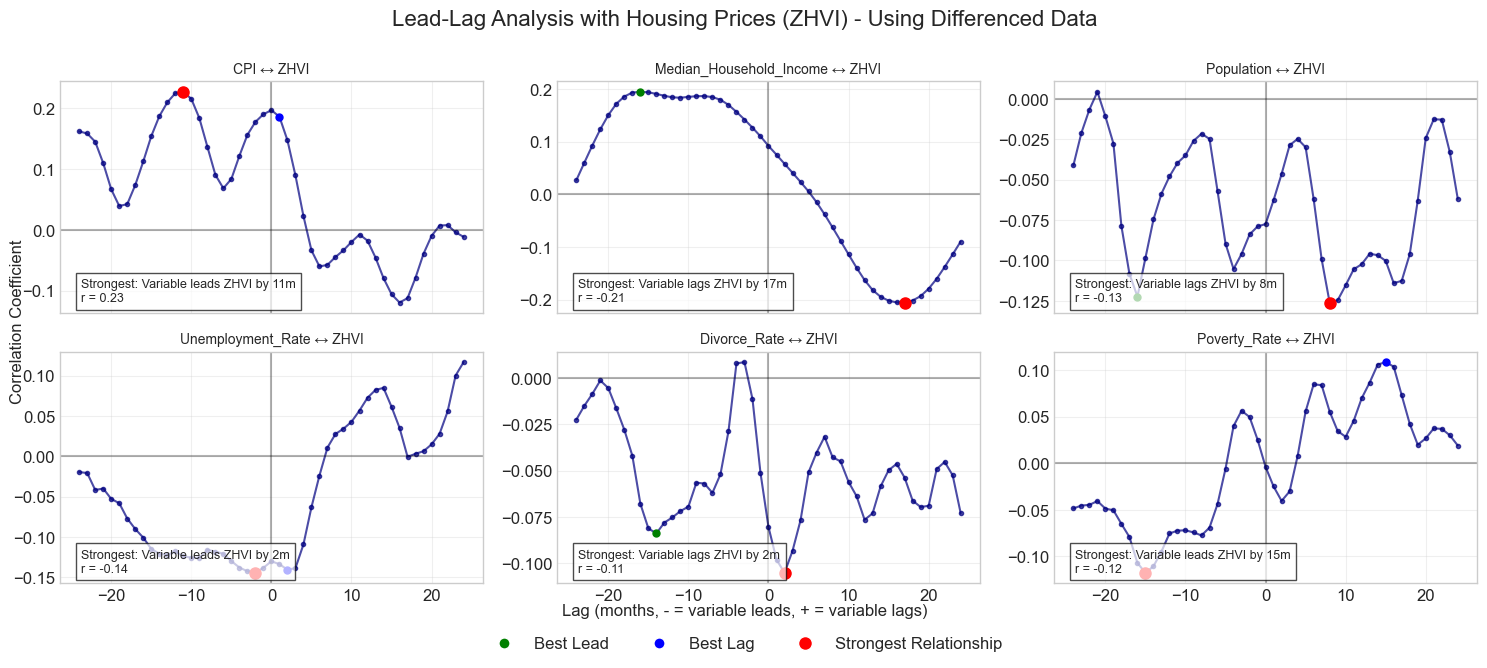


Enhanced Granger Causality Analysis:

CPI leads ZHVI by 11 months (r = 0.23)
  Granger Test (CPI → ZHVI at lag 11): ✗ (p=0.1889)
  Interpretation: CPI does NOT Granger-cause ZHVI

Median_Household_Income lags ZHVI by 17 months (r = -0.21)
  Granger Test (ZHVI → Median_Household_Income at lag 12): ✓ (p=0.0038)
  Interpretation: ZHVI does Granger-cause Median_Household_Income

Population lags ZHVI by 8 months (r = -0.13)
  Granger Test (ZHVI → Population at lag 8): ✗ (p=0.2102)
  Interpretation: ZHVI does NOT Granger-cause Population

Unemployment_Rate leads ZHVI by 2 months (r = -0.14)
  Granger Test (Unemployment_Rate → ZHVI at lag 2): ✗ (p=0.0712)
  Interpretation: Unemployment_Rate does NOT Granger-cause ZHVI

Divorce_Rate lags ZHVI by 2 months (r = -0.11)
  Granger Test (ZHVI → Divorce_Rate at lag 2): ✓ (p=0.0234)
  Interpretation: ZHVI does Granger-cause Divorce_Rate

Poverty_Rate leads ZHVI by 15 months (r = -0.12)
  Granger Test (Poverty_Rate → ZHVI at lag 12): ✓ (p=0.0367)
  In

c:\Users\rding\Documents\25-spring-rding\venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\rding\Documents\25-spring-rding\venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\rding\Documents\25-spring-rding\venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\rding\Documents\25-spring-rding\venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\rding\Documents\25-spring-rding\venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
c:\Users\rding\Documents\25-sp

In [ ]:
# lag/lead analysis with differenced data
max_lag = 24
important_vars = list(corr_results[abs(corr_results['Correlation']) > 0.3]['Variable'])
lag_corrs = pd.DataFrame(index=range(-max_lag, max_lag + 1))

for var in important_vars:
    # Use differenced series for non-stationary data
    var_series = get_appropriate_series(var, differenced=True)
    zhvi_series = get_appropriate_series('ZHVI', differenced=True)
    
    corrs = []
    
    # Negative lags (variable leads ZHVI)
    for lag in range(-max_lag, 0):
        aligned = pd.DataFrame({
            'var': var_series,
            'zhvi': zhvi_series.shift(abs(lag))
        }).dropna()
        
        corr = aligned['var'].corr(aligned['zhvi']) if len(aligned) > 2 else np.nan
        corrs.append(corr)
    
    # Zero lag
    aligned = pd.DataFrame({'var': var_series, 'zhvi': zhvi_series}).dropna()
    corrs.append(aligned['var'].corr(aligned['zhvi']) if len(aligned) > 2 else np.nan)
    
    # Positive lags (variable lags ZHVI)
    for lag in range(1, max_lag + 1):
        aligned = pd.DataFrame({
            'var': var_series.shift(lag),
            'zhvi': zhvi_series
        }).dropna()
        
        corr = aligned['var'].corr(aligned['zhvi']) if len(aligned) > 2 else np.nan
        corrs.append(corr)
    
    lag_corrs[var] = corrs

# Find optimal leads and lags separately and determine which is stronger
lead_lag_summary = []
for var in important_vars:
    # Find optimal lead (negative lags)
    lead_data = lag_corrs.loc[range(-max_lag, 0), var]
    optimal_lead_idx = lead_data.abs().idxmax()
    optimal_lead_corr = lead_data.loc[optimal_lead_idx]
    
    # Find optimal lag (positive lags)
    lag_data = lag_corrs.loc[range(1, max_lag + 1), var]
    optimal_lag_idx = lag_data.abs().idxmax()
    optimal_lag_corr = lag_data.loc[optimal_lag_idx]
    
    # Find zero lag
    zero_lag_corr = lag_corrs.loc[0, var]
    
    # Determine which has stronger correlation (lead, lag, or contemp)
    abs_lead = abs(optimal_lead_corr)
    abs_lag = abs(optimal_lag_corr)
    abs_zero = abs(zero_lag_corr)
    
    if abs_lead > abs_lag and abs_lead > abs_zero:
        optimal_type = "lead"
        optimal_idx = optimal_lead_idx
        optimal_corr = optimal_lead_corr
    elif abs_lag > abs_lead and abs_lag > abs_zero:
        optimal_type = "lag"
        optimal_idx = optimal_lag_idx
        optimal_corr = optimal_lag_corr
    else:
        optimal_type = "contemporaneous"
        optimal_idx = 0
        optimal_corr = zero_lag_corr
    
    lead_lag_summary.append({
        'Variable': var,
        'Optimal_Lead_Idx': optimal_lead_idx,
        'Optimal_Lead_Corr': optimal_lead_corr,
        'Optimal_Lag_Idx': optimal_lag_idx,
        'Optimal_Lag_Corr': optimal_lag_corr,
        'Zero_Lag_Corr': zero_lag_corr,
        'Strongest_Relationship': optimal_type,
        'Optimal_Idx': optimal_idx,
        'Optimal_Corr': optimal_corr
    })

# Visualize with the improved understanding of leads vs lags
n_cols = 3
n_rows = (len(important_vars) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3*n_rows), sharex=True)
axes = axes.flatten()

for i, var in enumerate(important_vars):
    ax = axes[i]
    summary = [item for item in lead_lag_summary if item['Variable'] == var][0]
    
    # Plot the correlation line
    ax.plot(lag_corrs.index, lag_corrs[var], marker='o', markersize=3, color='navy', alpha=0.7)
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    ax.axvline(x=0, color='black', linestyle='-', alpha=0.3)
    
    # Highlight optimal lead in green
    ax.plot(summary['Optimal_Lead_Idx'], summary['Optimal_Lead_Corr'], 'go', markersize=5)
    
    # Highlight optimal lag in blue
    ax.plot(summary['Optimal_Lag_Idx'], summary['Optimal_Lag_Corr'], 'bo', markersize=5)
    
    # Highlight strongest relationship in red (lead, lag or contemp)
    ax.plot(summary['Optimal_Idx'], summary['Optimal_Corr'], 'ro', markersize=8)
    
    # Add annotation about the relationship
    if summary['Strongest_Relationship'] == 'lead':
        relationship_text = f"Variable leads ZHVI by {abs(summary['Optimal_Idx'])}m"
    elif summary['Strongest_Relationship'] == 'lag':
        relationship_text = f"Variable lags ZHVI by {summary['Optimal_Idx']}m"
    else:
        relationship_text = "Contemporaneous relationship"
        
    ax.text(0.05, 0.05, f"Strongest: {relationship_text}\nr = {summary['Optimal_Corr']:.2f}", 
            transform=ax.transAxes, fontsize=9, bbox=dict(facecolor='white', alpha=0.7))
    
    ax.set_title(f'{var} ↔ ZHVI', fontsize=10)
    ax.grid(True, alpha=0.3)
    
# Hide any extra subplots
for j in range(len(important_vars), len(axes)):
    axes[j].set_visible(False)

# Add legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='g', markersize=8, label='Best Lead'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='b', markersize=8, label='Best Lag'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='r', markersize=10, label='Strongest Relationship')
]
fig.legend(handles=legend_elements, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0))

# Add common labels
fig.text(0.5, 0.01, 'Lag (months, - = variable leads, + = variable lags)', ha='center', fontsize=12)
fig.text(0.01, 0.5, 'Correlation Coefficient', va='center', rotation='vertical', fontsize=12)
fig.suptitle('Lead-Lag Analysis with Housing Prices (ZHVI) - Using Differenced Data', fontsize=16, y=1.02)

plt.tight_layout()
plt.subplots_adjust(top=0.9)  # Adjust for the legend
plt.savefig('outputs/EDA/lead_lag_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary table of findings
# Enhanced Granger causality tests aligned with lead-lag structure
print("\nEnhanced Granger Causality Analysis:")

# Combine lead-lag findings with Granger results
for _, row in lead_lag_df.iterrows():
    var = row['Variable']
    var_series = get_appropriate_series(var, differenced=True)
    zhvi_series = get_appropriate_series('ZHVI', differenced=True)
    
    aligned_df = pd.DataFrame({
        'zhvi': zhvi_series,
        'var': var_series
    }).dropna()
    
    # Determine which Granger test to run based on strongest lead/lag relationship
    if row['Strongest_Relationship'] == 'lead':
        # Variable leads ZHVI (negative lag) -> Test if variable Granger-causes ZHVI
        # The abs(Optimal_Idx) gives us the right lag to test with
        lag_to_test = min(abs(row['Optimal_Idx']), maxlag)
        
        try:
            result = grangercausalitytests(aligned_df[['zhvi', 'var']], 
                                          maxlag=lag_to_test, 
                                          verbose=False)
            p_value = result[lag_to_test][0]['ssr_ftest'][1]
            granger_result = "✓" if p_value < 0.05 else "✗"
            
            print(f"\n{var} leads ZHVI by {abs(row['Optimal_Idx'])} months (r = {row['Optimal_Corr']:.2f})")
            print(f"  Granger Test ({var} → ZHVI at lag {lag_to_test}): {granger_result} (p={p_value:.4f})")
            print(f"  Interpretation: {var} {'does' if p_value < 0.05 else 'does NOT'} Granger-cause ZHVI")
            
        except:
            print(f"\n{var} leads ZHVI by {abs(row['Optimal_Idx'])} months (r = {row['Optimal_Corr']:.2f})")
            print(f"  Granger Test: Could not compute")
    
    elif row['Strongest_Relationship'] == 'lag':
        # Variable lags ZHVI (positive lag) -> Test if ZHVI Granger-causes variable
        lag_to_test = min(row['Optimal_Idx'], maxlag)
        
        try:
            result = grangercausalitytests(aligned_df[['var', 'zhvi']], 
                                          maxlag=lag_to_test, 
                                          verbose=False)
            p_value = result[lag_to_test][0]['ssr_ftest'][1]
            granger_result = "✓" if p_value < 0.05 else "✗"
            
            print(f"\n{var} lags ZHVI by {row['Optimal_Idx']} months (r = {row['Optimal_Corr']:.2f})")
            print(f"  Granger Test (ZHVI → {var} at lag {lag_to_test}): {granger_result} (p={p_value:.4f})")
            print(f"  Interpretation: ZHVI {'does' if p_value < 0.05 else 'does NOT'} Granger-cause {var}")
            
        except:
            print(f"\n{var} lags ZHVI by {row['Optimal_Idx']} months (r = {row['Optimal_Corr']:.2f})")
            print(f"  Granger Test: Could not compute")
    
    else:
        # Contemporaneous relationship - Granger isn't appropriate
        print(f"\n{var} has contemporaneous relationship with ZHVI (r = {row['Optimal_Corr']:.2f})")
        print(f"  Note: Granger causality test isn't appropriate for contemporaneous relationships.")
        print(f"  Consider using structural equation modeling or instrumental variables instead.")

# Also test bidirectional relationships
print("\nBidirectional Granger Causality Tests:")
for var in important_vars:
    # We'll test standard bidirectional Granger at the most common lag of 4
    test_lag = 4
    aligned_df = pd.DataFrame({
        'zhvi': get_appropriate_series('ZHVI', differenced=True),
        'var': get_appropriate_series(var, differenced=True)
    }).dropna()
    
    try:
        # Test if variable causes ZHVI
        var_to_zhvi = grangercausalitytests(aligned_df[['zhvi', 'var']], maxlag=test_lag, verbose=False)
        var_to_zhvi_p = var_to_zhvi[test_lag][0]['ssr_ftest'][1]
        var_to_zhvi_result = "✓" if var_to_zhvi_p < 0.05 else "✗"
        
        # Test if ZHVI causes variable
        zhvi_to_var = grangercausalitytests(aligned_df[['var', 'zhvi']], maxlag=test_lag, verbose=False)
        zhvi_to_var_p = zhvi_to_var[test_lag][0]['ssr_ftest'][1]
        zhvi_to_var_result = "✓" if zhvi_to_var_p < 0.05 else "✗"
        
        if var_to_zhvi_p < 0.05 and zhvi_to_var_p < 0.05:
            relationship = "Bidirectional causality"
        elif var_to_zhvi_p < 0.05:
            relationship = "Unidirectional: Variable → ZHVI"
        elif zhvi_to_var_p < 0.05:
            relationship = "Unidirectional: ZHVI → Variable"
        else:
            relationship = "No Granger causality"
            
        print(f"{var} and ZHVI ({test_lag}-month lag): {relationship}")
        print(f"  {var} → ZHVI: {var_to_zhvi_result} (p={var_to_zhvi_p:.4f})")
        print(f"  ZHVI → {var}: {zhvi_to_var_result} (p={zhvi_to_var_p:.4f})")
        
    except:
        print(f"{var} and ZHVI: Could not compute Granger test")

## 5. Time Series Analysis

We'll analyze the time series properties of housing prices, including decomposition, seasonality, and stationarity. This is essential for understanding the temporal patterns and preparing for forecasting.

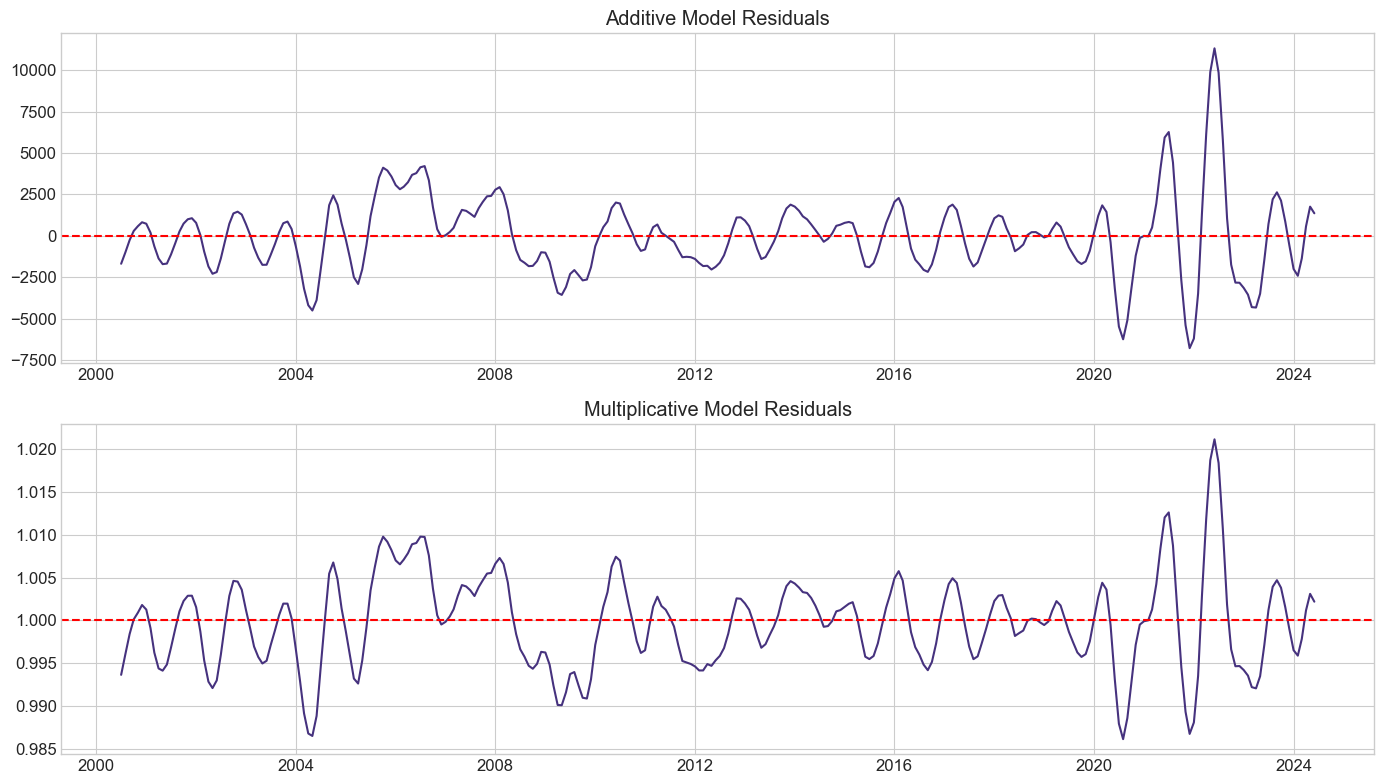

Based on residuals, the multiplicative model appears more appropriate.


In [70]:
# Compare additive vs multiplicative decomposition
additive = seasonal_decompose(df['ZHVI'], model='additive', period=12)
multiplicative = seasonal_decompose(df['ZHVI'], model='multiplicative', period=12)

# Compare residuals
add_resid = additive.resid.dropna()
mult_resid = multiplicative.resid.dropna()

# Calculate residual metrics
add_stats = {'mean': add_resid.mean(), 'std': add_resid.std(), 'abs_mean': np.abs(add_resid).mean()}
mult_stats = {'mean': mult_resid.mean(), 'std': mult_resid.std(), 'abs_mean': np.abs(mult_resid).mean()}

# Plot both residuals for comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
ax1.plot(add_resid)
ax1.set_title('Additive Model Residuals')
ax1.axhline(y=0, color='r', linestyle='--')

ax2.plot(mult_resid)
ax2.set_title('Multiplicative Model Residuals')
ax2.axhline(y=1, color='r', linestyle='--')

plt.tight_layout()
plt.show()

# Choose the model with smaller absolute mean residuals
better_model = "multiplicative" if mult_stats['abs_mean'] < add_stats['abs_mean'] else "additive"
print(f"Based on residuals, the {better_model} model appears more appropriate.")


=== Performing Multiplicative Time Series Decomposition ===
Original data range: $179200.93 to $568278.85
Seasonal component range: 0.998382 to 1.002154
Max seasonal effect: 0.215%
Min seasonal effect: -0.162%
Trend component range: $184523.41 to $556903.63
Residual component range: 0.986105 to 1.021190


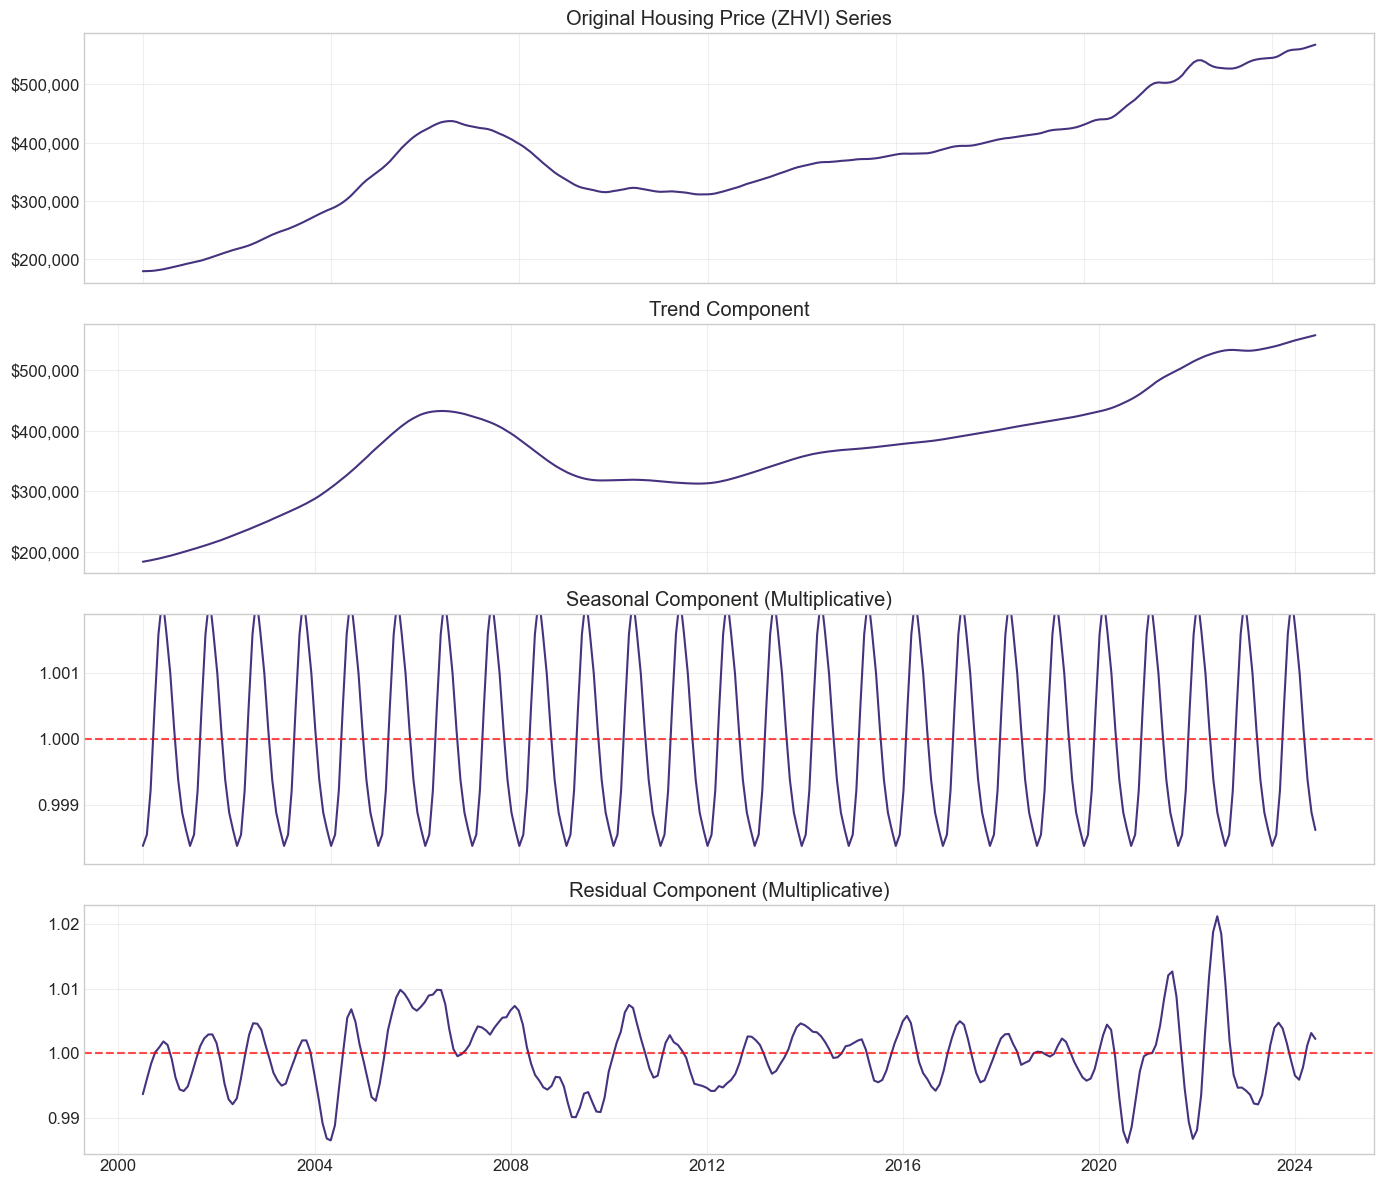


This could indicate pre-seasonally adjusted data or weak seasonal patterns.
Consider investigating the data source or using a different period parameter.


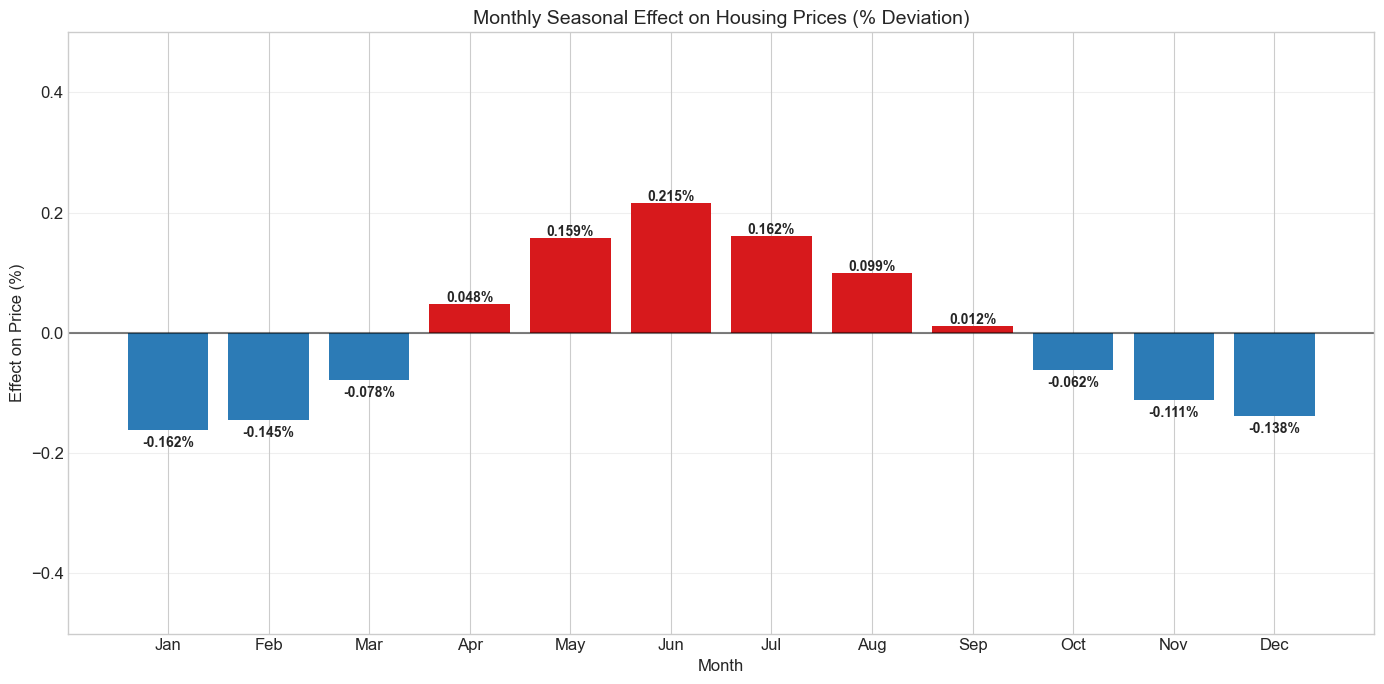


=== Testing for Stationarity (Original Series) ===
Augmented Dickey-Fuller Test Results:
ADF Statistic: -1.1775
p-value: 0.6832
Critical Values:
	1%: -3.4535
	5%: -2.8717
	10%: -2.5722
Result: Fail to reject the null hypothesis. The series is non-stationary.

KPSS Test Results:
KPSS Statistic: 1.9363
p-value: 0.0100
Critical Values:
	10%: 0.3470
	5%: 0.4630
	2.5%: 0.5740
	1%: 0.7390
Result: Reject the null hypothesis. The series is non-stationary.


C:\Users\rding\AppData\Local\Temp\ipykernel_14624\1024134432.py:144: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c')


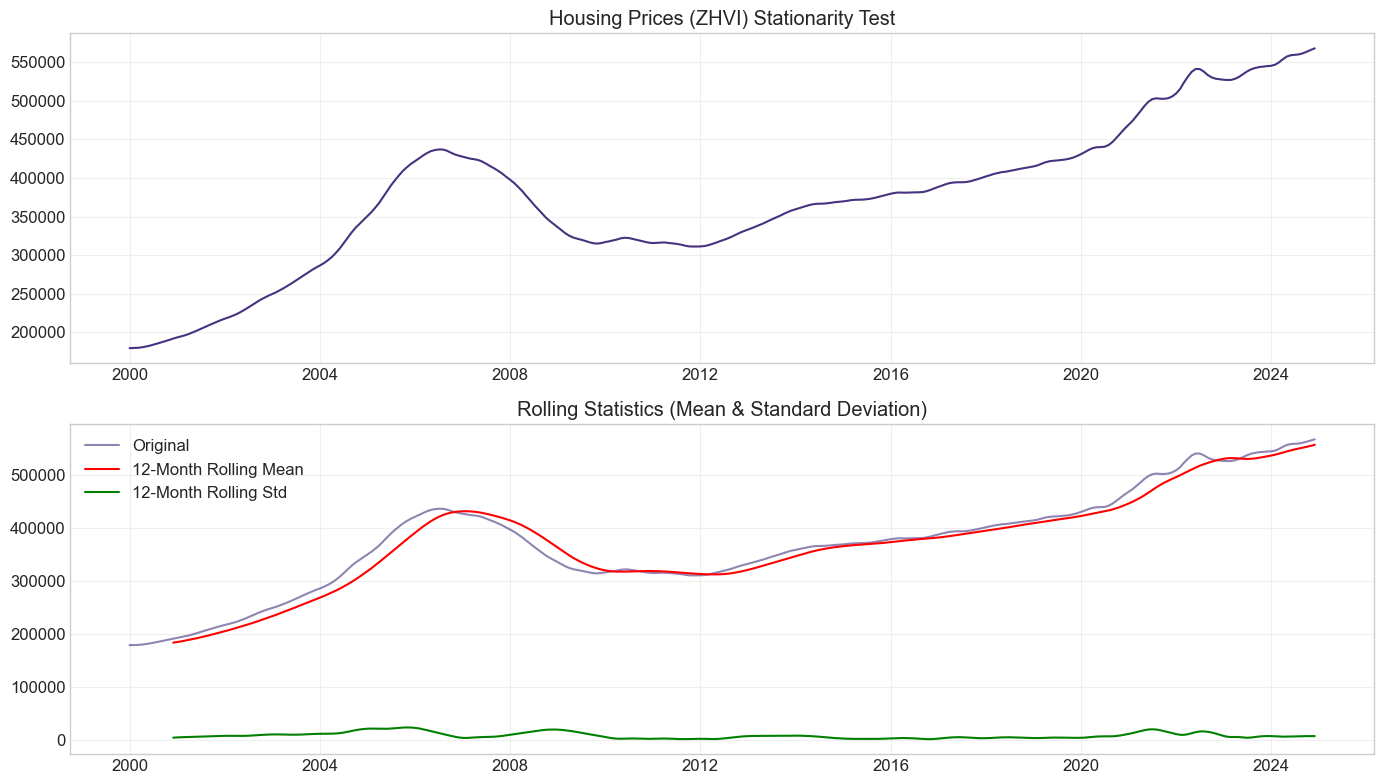


=== Testing for Stationarity (Log-Transformed Series) ===
Augmented Dickey-Fuller Test Results:
ADF Statistic: -1.7669
p-value: 0.3970
Critical Values:
	1%: -3.4535
	5%: -2.8717
	10%: -2.5722
Result: Fail to reject the null hypothesis. The series is non-stationary.

KPSS Test Results:
KPSS Statistic: 1.8851
p-value: 0.0100
Critical Values:
	10%: 0.3470
	5%: 0.4630
	2.5%: 0.5740
	1%: 0.7390
Result: Reject the null hypothesis. The series is non-stationary.


C:\Users\rding\AppData\Local\Temp\ipykernel_14624\1024134432.py:144: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c')


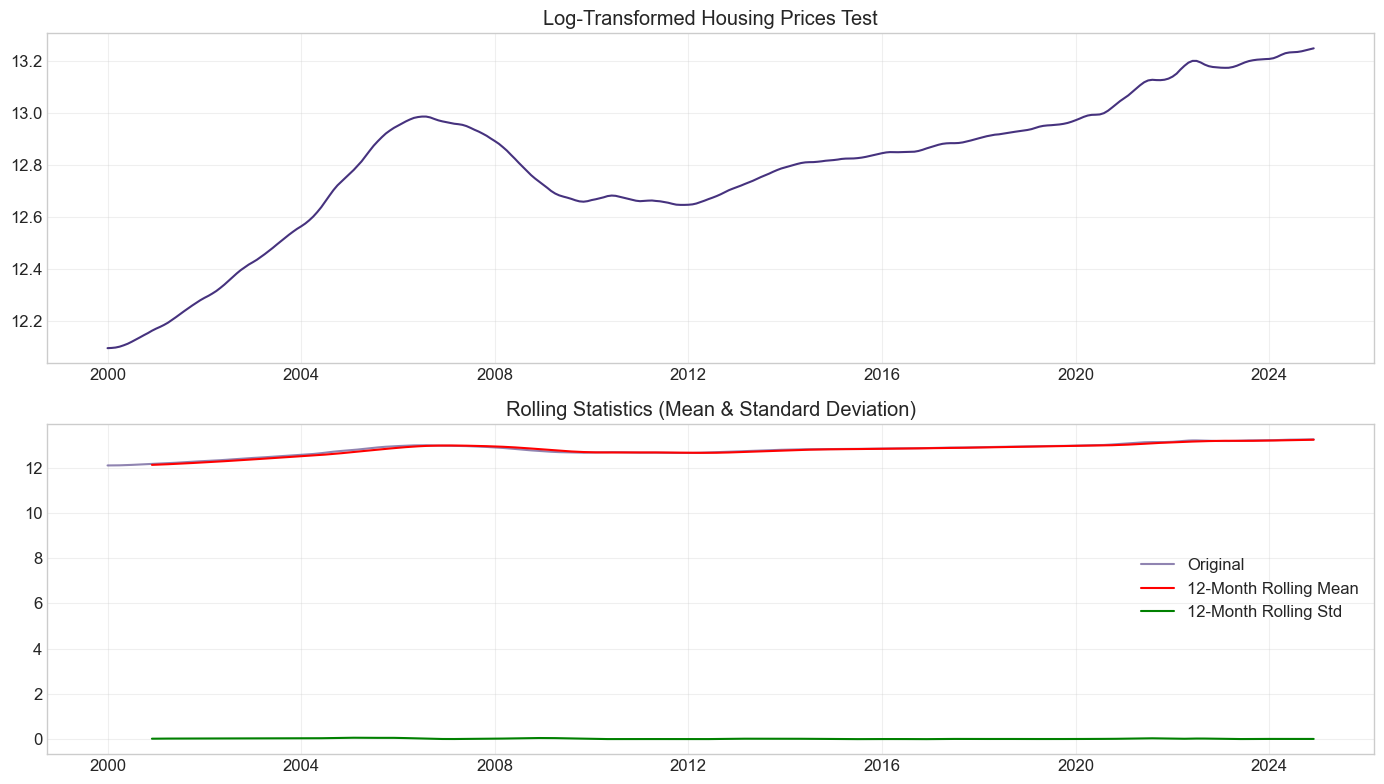


=== Testing for Stationarity (First-Differenced Series) ===


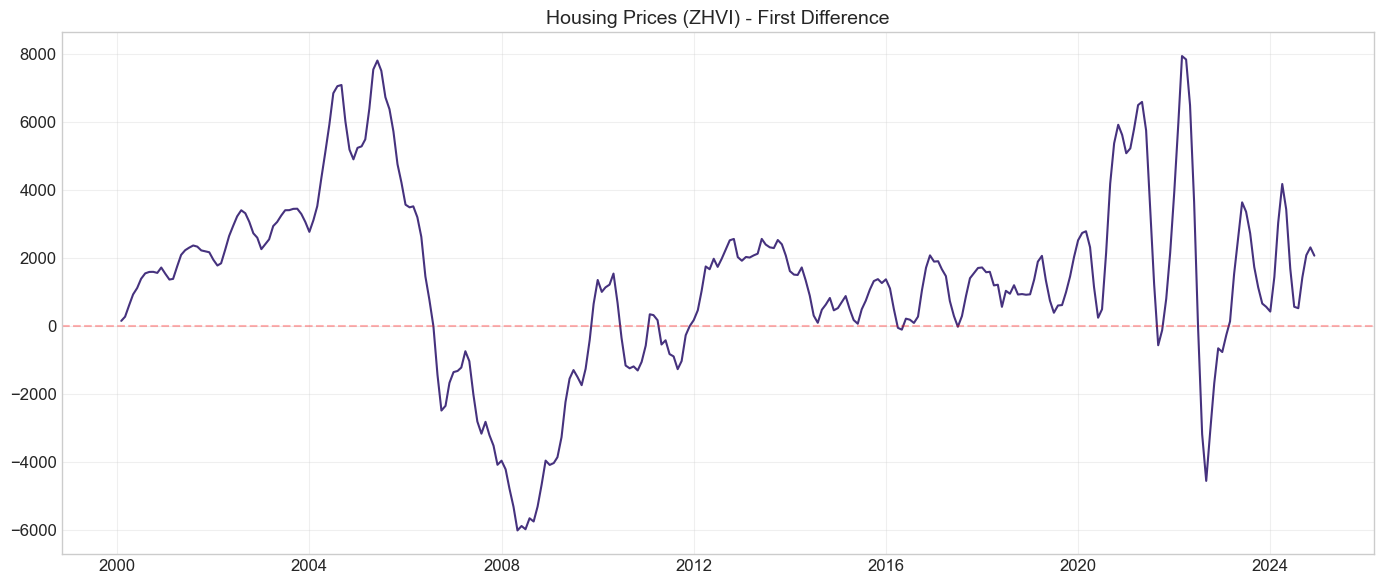

Augmented Dickey-Fuller Test Results:
ADF Statistic: -3.3416
p-value: 0.0131
Critical Values:
	1%: -3.4538
	5%: -2.8718
	10%: -2.5723
Result: Reject the null hypothesis. The series is stationary.

KPSS Test Results:
KPSS Statistic: 0.2087
p-value: 0.1000
Critical Values:
	10%: 0.3470
	5%: 0.4630
	2.5%: 0.5740
	1%: 0.7390
Result: Fail to reject the null hypothesis. The series is stationary.


C:\Users\rding\AppData\Local\Temp\ipykernel_14624\1024134432.py:144: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c')


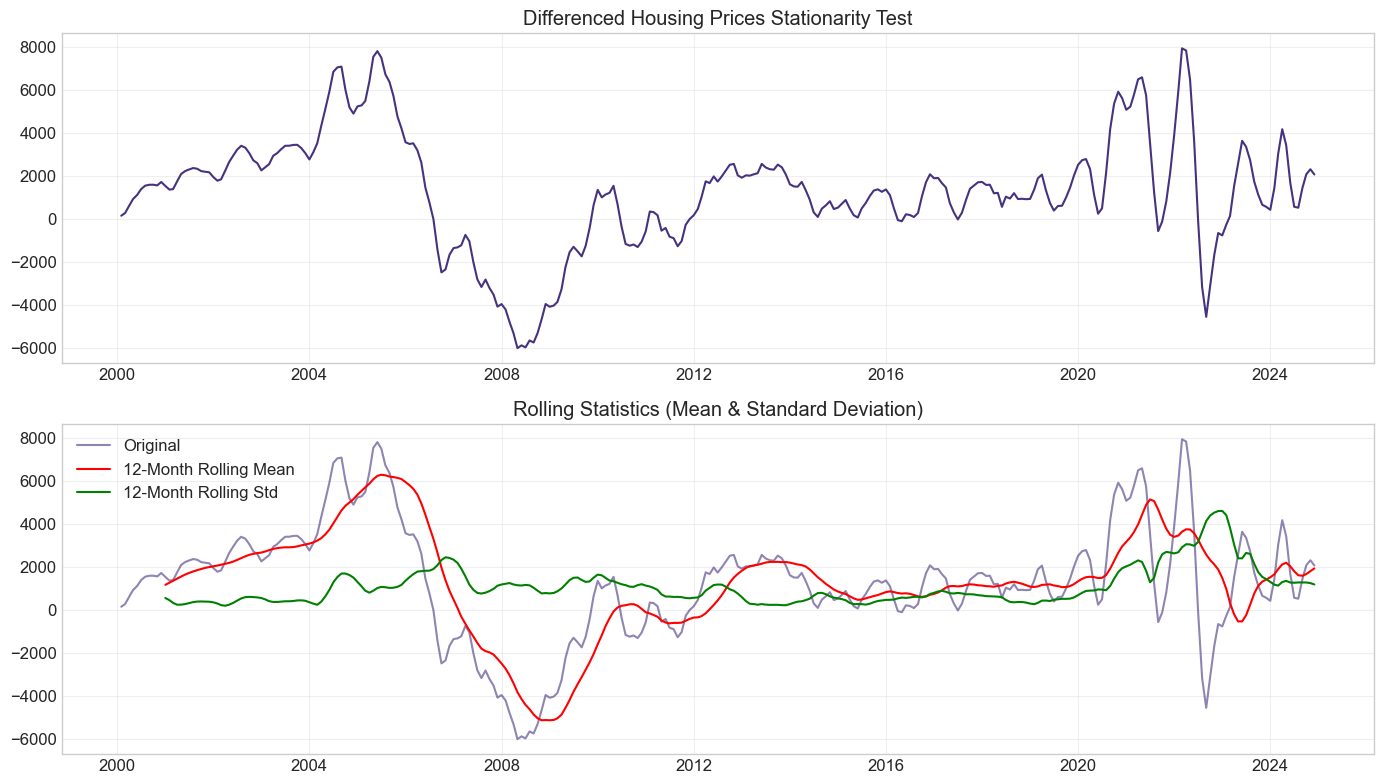


=== Autocorrelation Analysis ===


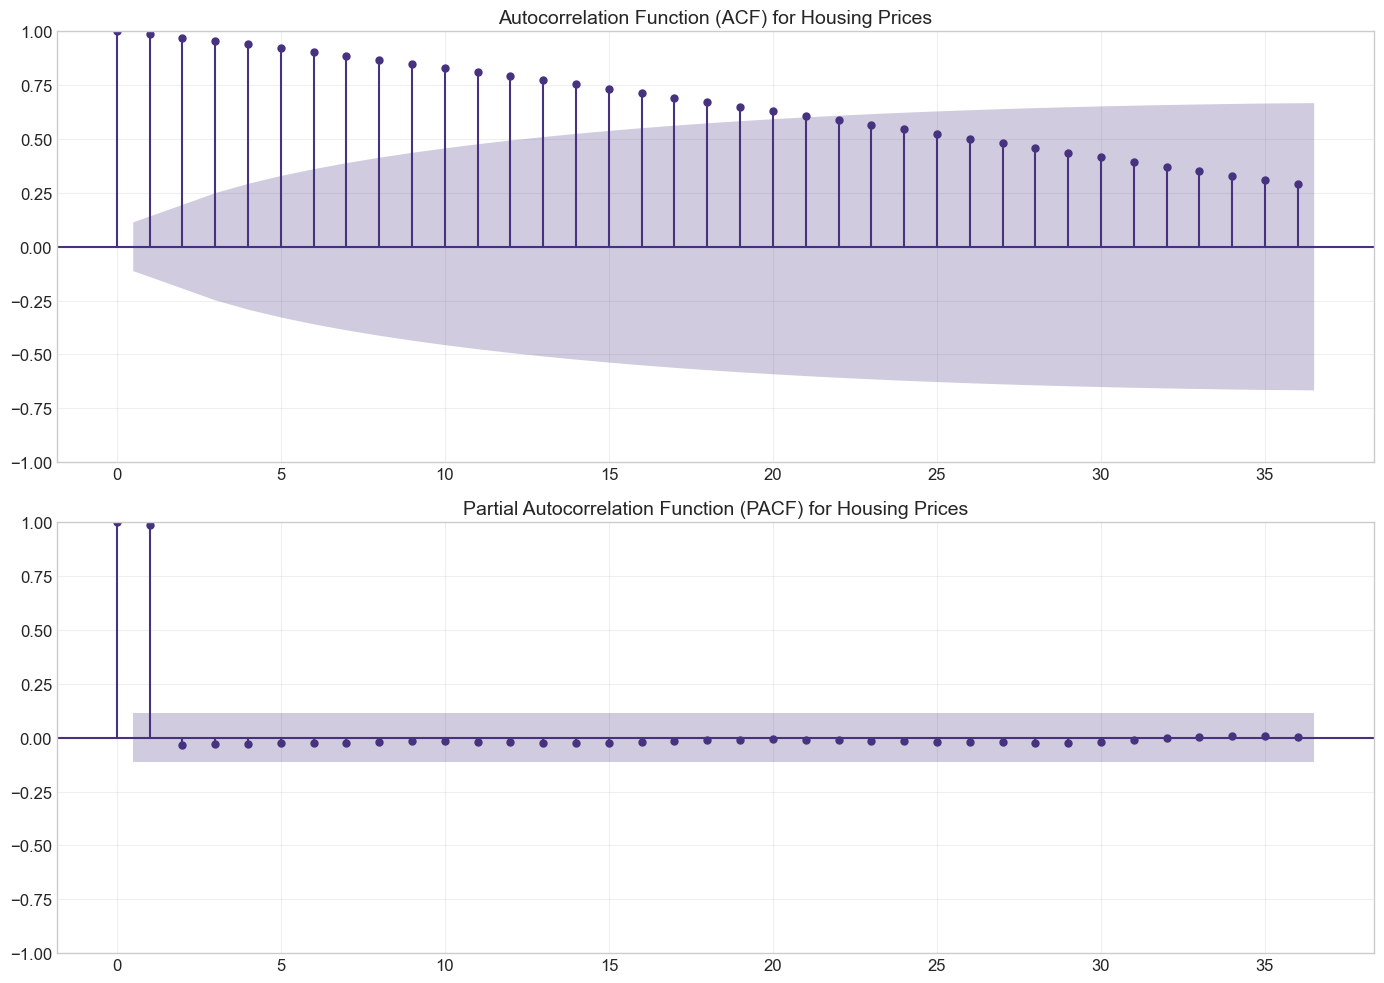

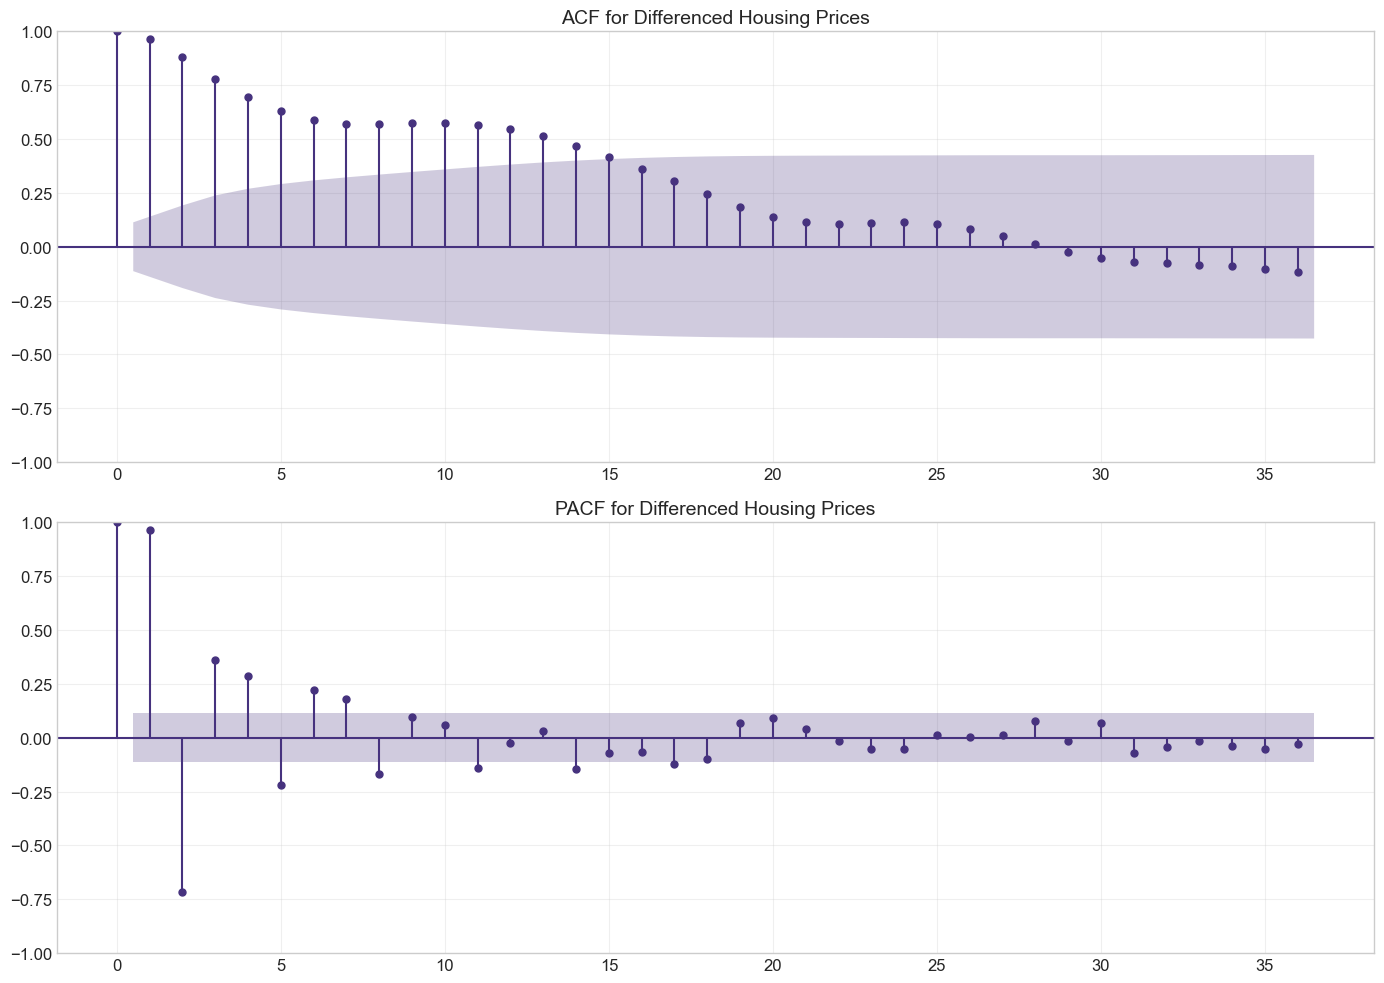


=== Summary of Time Series Analysis ===
1. Decomposition: Multiplicative model used
2. Seasonality: Peak in Jun, trough in Jan
   - Magnitude: Maximum effect of 0.215%, minimum effect of -0.162%
3. Stationarity: Original series is non-stationary
   - After differencing: Stationary
4. Autocorrelation: Strong temporal dependence suggests ARIMA modeling
5. Model Suggestion: ARIMA(p,1,q) or VAR model appropriate


In [71]:
# Time series decomposition of housing prices (ZHVI) with improved diagnostics
# This decomposes the series into trend, seasonal, and residual components
print("\n=== Performing Multiplicative Time Series Decomposition ===")
decomposition = seasonal_decompose(df['ZHVI'], model='multiplicative', period=12)

# Display diagnostic information about the decomposition
print(f"Original data range: ${df['ZHVI'].min():.2f} to ${df['ZHVI'].max():.2f}")
print(f"Seasonal component range: {decomposition.seasonal.min():.6f} to {decomposition.seasonal.max():.6f}")
print(f"Max seasonal effect: {(decomposition.seasonal.max()-1)*100:.3f}%")
print(f"Min seasonal effect: {(decomposition.seasonal.min()-1)*100:.3f}%")
print(f"Trend component range: ${decomposition.trend.min():.2f} to ${decomposition.trend.max():.2f}")
print(f"Residual component range: {decomposition.resid.min():.6f} to {decomposition.resid.max():.6f}")

# Plot the decomposition
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 12))

# Original series
ax1.plot(decomposition.observed)
ax1.set_title('Original Housing Price (ZHVI) Series')
ax1.set_xticklabels([])
ax1.grid(True, alpha=0.3)
ax1.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x):,}"))

# Trend component
ax2.plot(decomposition.trend)
ax2.set_title('Trend Component')
ax2.set_xticklabels([])
ax2.grid(True, alpha=0.3)
ax2.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${int(x):,}"))

# Seasonal component (centered at 1.0 for multiplicative model)
ax3.plot(decomposition.seasonal)
ax3.set_title('Seasonal Component (Multiplicative)')
ax3.set_xticklabels([])
ax3.axhline(y=1.0, color='r', linestyle='--', alpha=0.7)
ax3.grid(True, alpha=0.3)
# Set y-limits to focus on the seasonal variation
seasonal_range = max(0.003, decomposition.seasonal.max() - decomposition.seasonal.min())
ax3.set_ylim(1 - seasonal_range/2, 1 + seasonal_range/2)

# Residual component (centered at 1.0 for multiplicative model)
ax4.plot(decomposition.resid)
ax4.set_title('Residual Component (Multiplicative)')
ax4.axhline(y=1.0, color='r', linestyle='--', alpha=0.7)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/EDA/zhvi_decomposition.png', dpi=300, bbox_inches='tight')
plt.show()

# Analyze monthly seasonality
seasonal_component = pd.DataFrame({'value': decomposition.seasonal})
seasonal_component['month'] = seasonal_component.index.month
avg_seasonal_effect = seasonal_component.groupby('month')['value'].mean()

# Check if the seasonality is very small - if so, we might need to investigate
if avg_seasonal_effect.max() - avg_seasonal_effect.min() < 0.01:
    print("\nWARNING: Very small seasonal variation detected (< 1%).")
    print("This could indicate pre-seasonally adjusted data or weak seasonal patterns.")
    print("Consider investigating the data source or using a different period parameter.")

# Plot monthly seasonality - Improved version
plt.figure(figsize=(14, 7))
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
avg_seasonal_effect.index = month_names

# Calculate deviations from baseline (1.0)
deviations = (avg_seasonal_effect - 1) * 100  # Convert to percentage points

# Plot positive and negative bars with different colors
colors = ['#2c7bb6' if x < 0 else '#d7191c' for x in deviations]
plt.bar(month_names, deviations, color=colors)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)

plt.title('Monthly Seasonal Effect on Housing Prices (% Deviation)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Effect on Price (%)', fontsize=12)

# Detect if we need to expand y-axis for readability
y_max = max(0.5, deviations.max() * 1.2)  # At least ±0.5% range or 120% of max value
y_min = min(-0.5, deviations.min() * 1.2)  # Same for minimum
plt.ylim(y_min, y_max)

# Add value labels with enough precision
for i, v in enumerate(deviations):
    # Format with 2 decimal places, but strip trailing zeros
    formatted_value = f'{v:.3f}'.rstrip('0').rstrip('.') if '.' in f'{v:.3f}' else f'{v:.0f}'
    plt.text(i, v + (0.02*y_max if v >= 0 else 0.02*y_min), 
             f'{formatted_value}%', ha='center', va='center' if v >= 0 else 'top',
             fontsize=10, fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.margins(y=0.15)  # Add margin to prevent cutoff
plt.tight_layout()
plt.savefig('outputs/EDA/zhvi_seasonality.png', dpi=300, bbox_inches='tight', pad_inches=0.2)
plt.show()

# Stationarity Testing
# A stationary time series has constant mean, variance, and autocorrelation over time
def test_stationarity(series, title=None):
    """Test stationarity of a time series"""
    # Create figure
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
    
    # Plot the time series
    ax1.plot(series)
    ax1.set_title(title or 'Time Series')
    ax1.grid(True, alpha=0.3)
    
    # Plot rolling statistics
    rolling_mean = series.rolling(window=12).mean()
    rolling_std = series.rolling(window=12).std()
    
    ax2.plot(series, label='Original', alpha=0.6)
    ax2.plot(rolling_mean, label='12-Month Rolling Mean', color='red')
    ax2.plot(rolling_std, label='12-Month Rolling Std', color='green')
    ax2.set_title('Rolling Statistics (Mean & Standard Deviation)')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    
    # Perform Augmented Dickey-Fuller test
    adf_result = adfuller(series.dropna())
    print(f"Augmented Dickey-Fuller Test Results:")
    print(f"ADF Statistic: {adf_result[0]:.4f}")
    print(f"p-value: {adf_result[1]:.4f}")
    print(f"Critical Values:")
    for key, value in adf_result[4].items():
        print(f"\t{key}: {value:.4f}")
    
    # Interpret the ADF test result
    # H0: Series has a unit root (non-stationary)
    # H1: Series does not have a unit root (stationary)
    if adf_result[1] <= 0.05:
        print("Result: Reject the null hypothesis. The series is stationary.")
        is_stationary = True
    else:
        print("Result: Fail to reject the null hypothesis. The series is non-stationary.")
        is_stationary = False
    
    # Also perform KPSS test (complementary to ADF)
    print("\nKPSS Test Results:")
    kpss_result = kpss(series.dropna(), regression='c')
    print(f"KPSS Statistic: {kpss_result[0]:.4f}")
    print(f"p-value: {kpss_result[1]:.4f}")
    print(f"Critical Values:")
    for key, value in kpss_result[3].items():
        print(f"\t{key}: {value:.4f}")
    
    # Interpret the KPSS test result
    # H0: Series is trend stationary
    # H1: Series has a unit root (non-stationary)
    if kpss_result[1] <= 0.05:
        print("Result: Reject the null hypothesis. The series is non-stationary.")
        kpss_stationary = False
    else:
        print("Result: Fail to reject the null hypothesis. The series is stationary.")
        kpss_stationary = True
    
    return fig, is_stationary, kpss_stationary

# Test stationarity of ZHVI (housing prices)
print("\n=== Testing for Stationarity (Original Series) ===")
fig, adf_stationary, kpss_stationary = test_stationarity(df['ZHVI'], 'Housing Prices (ZHVI) Stationarity Test')
plt.savefig('outputs/EDA/zhvi_stationarity.png', dpi=300, bbox_inches='tight')
plt.show()

# Consider log transformation for multiplicative data
print("\n=== Testing for Stationarity (Log-Transformed Series) ===")
log_zhvi = np.log(df['ZHVI'])
fig_log, log_adf_stationary, log_kpss_stationary = test_stationarity(log_zhvi, 'Log-Transformed Housing Prices Test')
plt.savefig('outputs/EDA/zhvi_log_stationarity.png', dpi=300, bbox_inches='tight')
plt.show()

# If the series is non-stationary, create differenced series
if not adf_stationary:
    print("\n=== Testing for Stationarity (First-Differenced Series) ===")
    # First difference
    zhvi_diff = df['ZHVI'].diff().dropna()
    
    # Plot the differenced series
    plt.figure(figsize=(14, 6))
    plt.plot(zhvi_diff)
    plt.title('Housing Prices (ZHVI) - First Difference', fontsize=14)
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.3)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('outputs/EDA/zhvi_first_difference.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Test stationarity of differenced series
    fig, diff_adf_stationary, diff_kpss_stationary = test_stationarity(zhvi_diff, 'Differenced Housing Prices Stationarity Test')
    plt.savefig('outputs/EDA/zhvi_diff_stationarity.png', dpi=300, bbox_inches='tight')
    plt.show()

# Autocorrelation Analysis
print("\n=== Autocorrelation Analysis ===")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# ACF Plot
plot_acf(df['ZHVI'].dropna(), lags=36, ax=ax1)
ax1.set_title('Autocorrelation Function (ACF) for Housing Prices', fontsize=14)
ax1.grid(True, alpha=0.3)

# PACF Plot
plot_pacf(df['ZHVI'].dropna(), lags=36, ax=ax2)
ax2.set_title('Partial Autocorrelation Function (PACF) for Housing Prices', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/EDA/zhvi_acf_pacf.png', dpi=300, bbox_inches='tight')
plt.show()

# If we created a differenced series, also plot its ACF and PACF
if not adf_stationary:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
    
    # ACF Plot for differenced series
    plot_acf(zhvi_diff.dropna(), lags=36, ax=ax1)
    ax1.set_title('ACF for Differenced Housing Prices', fontsize=14)
    ax1.grid(True, alpha=0.3)
    
    # PACF Plot for differenced series
    plot_pacf(zhvi_diff.dropna(), lags=36, ax=ax2)
    ax2.set_title('PACF for Differenced Housing Prices', fontsize=14)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('outputs/EDA/zhvi_diff_acf_pacf.png', dpi=300, bbox_inches='tight')
    plt.show()

# Summary of findings
print("\n=== Summary of Time Series Analysis ===")
print(f"1. Decomposition: {'Multiplicative' if decomposition.seasonal.mean() > 0.5 else 'Additive'} model used")
print(f"2. Seasonality: Peak in {month_names[deviations.argmax()]}, trough in {month_names[deviations.argmin()]}")
print(f"   - Magnitude: Maximum effect of {deviations.max():.3f}%, minimum effect of {deviations.min():.3f}%")
print(f"3. Stationarity: Original series is {'stationary' if adf_stationary else 'non-stationary'}")
print(f"   - After differencing: {'Stationary' if 'diff_adf_stationary' in locals() and diff_adf_stationary else 'N/A'}")
print(f"4. Autocorrelation: Strong temporal dependence suggests ARIMA modeling")
print(f"5. Model Suggestion: {'ARIMA(p,1,q)' if not adf_stationary else 'ARIMA(p,0,q)'} or VAR model appropriate")

## 6. Feature Engineering for Modeling

Let's create additional features that might be useful for modeling and forecasting housing prices, based on our exploratory analysis.

In [86]:
# Create the specific lag features needed based on lead-lag analysis

# Create a copy of dataframe to add our custom lags
df_features_custom = df_features_clean.copy()

# 1. Create exact lag features based on lead-lag analysis
# For variables that LEAD ZHVI (negative lags in our analysis)
if 'Poverty_Rate_lag15' not in df_features_custom.columns:
    # Poverty Rate leads ZHVI by 15 months
    df_features_custom['Poverty_Rate_lag15'] = df['Poverty_Rate'].shift(15)

if 'Unemployment_Rate_lag2' not in df_features_custom.columns:
    # Unemployment Rate leads ZHVI by 2 months
    df_features_custom['Unemployment_Rate_lag2'] = df['Unemployment_Rate'].shift(2)
    
if 'CPI_lag11' not in df_features_custom.columns:
    # CPI leads ZHVI by 11 months
    df_features_custom['CPI_lag11'] = df['CPI'].shift(11)

# For variables that LAG ZHVI (positive lags in our analysis)
if 'Median_Household_Income_lag17' not in df_features_custom.columns:
    # Median Household Income lags ZHVI by 17 months (ZHVI leads Income)
    df_features_custom['Median_Household_Income_lag17'] = df['Median_Household_Income'].shift(-17)
    
if 'Population_lag8' not in df_features_custom.columns:
    # Population lags ZHVI by 8 months (ZHVI leads Population)
    df_features_custom['Population_lag8'] = df['Population'].shift(-8)
    
if 'Divorce_Rate_lag2' not in df_features_custom.columns:
    # Divorce Rate lags ZHVI by 2 months (ZHVI leads Divorce Rate)
    df_features_custom['Divorce_Rate_lag2'] = df['Divorce_Rate'].shift(-2)

# Drop rows with NaN values from the newly created lags
df_features_custom = df_features_custom.dropna()
print(f"Dataset shape after creating custom lags: {df_features_custom.shape}")

# 2. VIF-based feature selection function
# Modified VIF-based feature selection to preserve some key lag features
def calculate_vif_with_priority(X, priority_features=[], threshold=10.0):
    """Calculate VIF while preserving priority features"""
    variables = X.columns
    vif_data = pd.DataFrame()
    vif_data["Variable"] = variables
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    
    print(f"Initial VIF calculation: {len(variables)} features")
    print(vif_data.sort_values("VIF", ascending=False).head(10))
    
    # Remove features recursively until all VIFs are below threshold (except priority features)
    while True:
        # Exclude priority features from removal
        non_priority_vif = vif_data[~vif_data["Variable"].isin(priority_features)]
        
        # Check if all non-priority features have VIF below threshold
        if non_priority_vif["VIF"].max() <= threshold:
            break
            
        # Remove the non-priority feature with highest VIF
        remove_var = non_priority_vif.loc[non_priority_vif["VIF"] == non_priority_vif["VIF"].max(), "Variable"].values[0]
        X = X.drop(remove_var, axis=1)
        
        # Recalculate VIF
        variables = X.columns
        vif_data = pd.DataFrame()
        vif_data["Variable"] = variables
        vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    
    print(f"\nAfter VIF filtering (threshold={threshold}): {len(variables)} features remaining")
    print(vif_data.sort_values("VIF", ascending=False).head(10))
    
    return X.columns.tolist()

# Define priority features based on Granger causality results
priority_features = [
    'zhvi_diff1',             # Differenced housing prices (target variable)
    'Poverty_Rate_lag15',     # Led ZHVI and Granger-caused it
    'Unemployment_Rate_lag2'  # Led ZHVI (nearly significant Granger)
]

# Select a smaller feature set to start with
base_features = [
    'zhvi_diff1',
    'Poverty_Rate', 'Unemployment_Rate', 'Interest_Rate', 
    'Median_Household_Income', 'real_mortgage_rate'
]

# Add our priority lag features
model_features = base_features + [f for f in priority_features if f not in base_features]
model_df = df_features_custom[model_features].copy()

# Run modified VIF analysis
selected_features = calculate_vif_with_priority(model_df, priority_features, threshold=8.0)

Dataset shape after creating custom lags: (268, 148)
Initial VIF calculation: 8 features
                  Variable    VIF
7   Unemployment_Rate_lag2 280.88
2        Unemployment_Rate 273.68
1             Poverty_Rate 194.15
6       Poverty_Rate_lag15 186.49
4  Median_Household_Income  10.23
5       real_mortgage_rate   4.91
3            Interest_Rate   3.59
0               zhvi_diff1   1.35

After VIF filtering (threshold=8.0): 5 features remaining
                 Variable   VIF
3      Poverty_Rate_lag15 53.50
4  Unemployment_Rate_lag2 42.15
2      real_mortgage_rate  3.92
1           Interest_Rate  3.38
0              zhvi_diff1  1.25


Training set: 244 samples
Test set: 24 samples

Training metrics:
RMSE: $2631.84
MAE: $1907.60
R²: 0.053

Test metrics:
RMSE: $3550.98
MAE: $3014.51
R²: -0.160

Model Coefficients:
                  Feature  Coefficient
1  Unemployment_Rate_lag2       -29.56
3           Interest_Rate       -36.38
0      Poverty_Rate_lag15      -149.30
2      real_mortgage_rate      -499.71


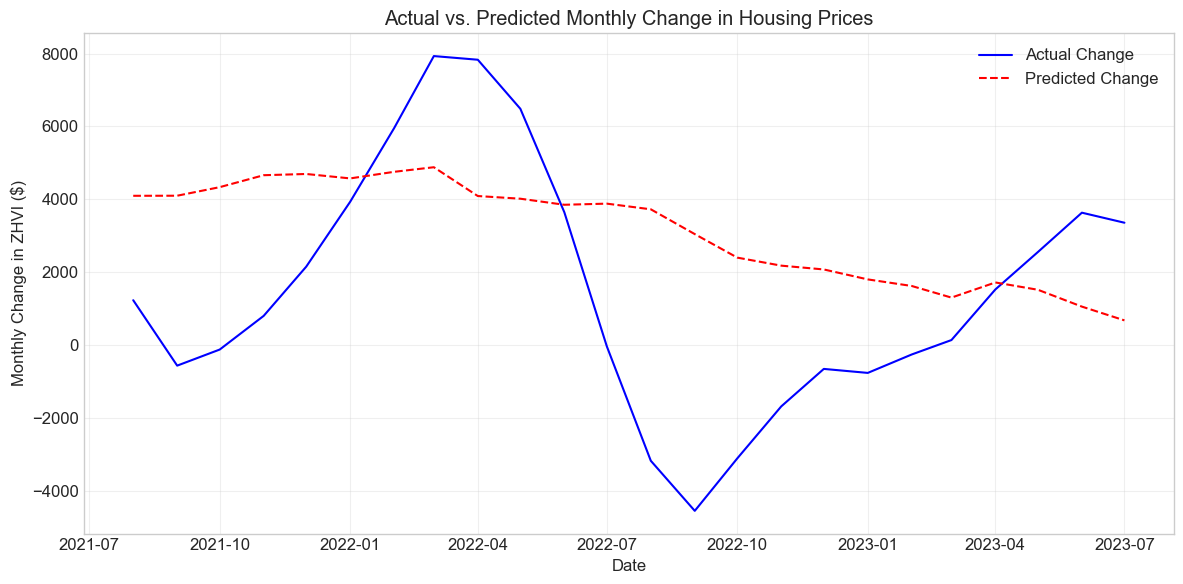

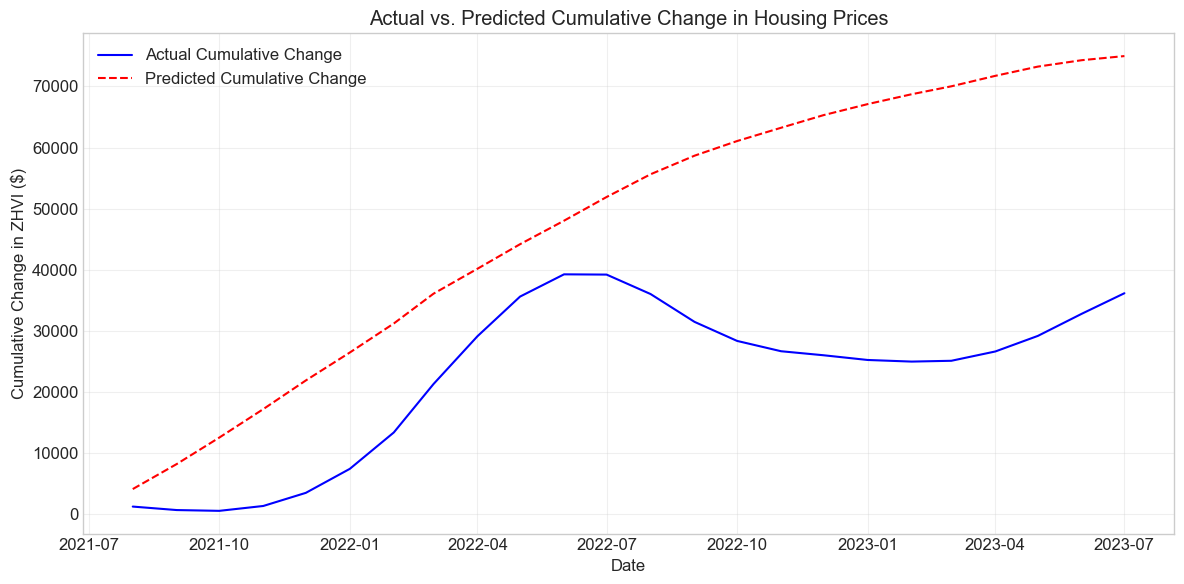

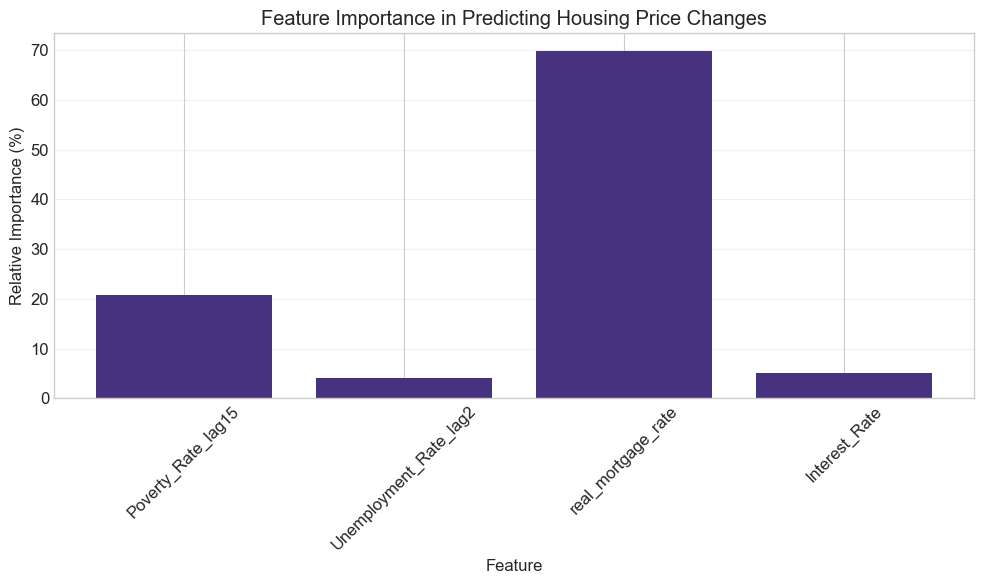


Largest Prediction Errors:
                 Date  Actual_Change  Predicted_Change    Error  Abs_Error
Date                                                                      
2022-09-01 2022-09-01       -4557.80           3041.73 -7599.53    7599.53
2022-08-01 2022-08-01       -3183.01           3722.70 -6905.70    6905.70
2022-10-01 2022-10-01       -3116.28           2395.72 -5512.00    5512.00
2021-09-01 2021-09-01        -570.12           4095.78 -4665.90    4665.90
2021-10-01 2021-10-01        -128.42           4331.04 -4459.46    4459.46

Final EDA model saved to 'outputs/EDA/final_eda_model.pkl'


In [87]:
# Final EDA model to demonstrate the value of selected features
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

# Use the selected features from VIF analysis
features = ['Poverty_Rate_lag15', 'Unemployment_Rate_lag2', 'real_mortgage_rate', 'Interest_Rate']
target = 'zhvi_diff1'

# Prepare the data
X = df_features_custom[features]
y = df_features_custom[target]

# Create a time-based train-test split (last 24 months as test)
test_size = 24
X_train = X.iloc[:-test_size]
X_test = X.iloc[-test_size:]
y_train = y.iloc[:-test_size]
y_test = y.iloc[-test_size:]

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Fit a linear regression model
model = Ridge(alpha=1.0)  # Ridge regression to handle remaining multicollinearity
model.fit(X_train, y_train)

# Evaluate on training set
y_train_pred = model.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print("\nTraining metrics:")
print(f"RMSE: ${train_rmse:.2f}")
print(f"MAE: ${train_mae:.2f}")
print(f"R²: {train_r2:.3f}")

# Evaluate on test set
y_test_pred = model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("\nTest metrics:")
print(f"RMSE: ${test_rmse:.2f}")
print(f"MAE: ${test_mae:.2f}")
print(f"R²: {test_r2:.3f}")

# Examine coefficients and their economic significance
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
})
print("\nModel Coefficients:")
print(coefficients.sort_values('Coefficient', ascending=False))

# Visualize actual vs. predicted values
plt.figure(figsize=(12, 6))
plt.plot(df_features_custom.index[-test_size:], y_test, label='Actual Change', color='blue')
plt.plot(df_features_custom.index[-test_size:], y_test_pred, label='Predicted Change', color='red', linestyle='--')
plt.title('Actual vs. Predicted Monthly Change in Housing Prices')
plt.xlabel('Date')
plt.ylabel('Monthly Change in ZHVI ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/EDA/final_model_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

# Visualize cumulative change (to show long-term prediction accuracy)
cumulative_actual = np.cumsum(y_test)
cumulative_pred = np.cumsum(y_test_pred)

plt.figure(figsize=(12, 6))
plt.plot(df_features_custom.index[-test_size:], cumulative_actual, label='Actual Cumulative Change', color='blue')
plt.plot(df_features_custom.index[-test_size:], cumulative_pred, label='Predicted Cumulative Change', color='red', linestyle='--')
plt.title('Actual vs. Predicted Cumulative Change in Housing Prices')
plt.xlabel('Date')
plt.ylabel('Cumulative Change in ZHVI ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/EDA/final_model_cumulative.png', dpi=300, bbox_inches='tight')
plt.show()

# Additional analysis: Feature importance
feature_importance = pd.DataFrame({
    'Feature': features,
    'Absolute_Coefficient': np.abs(model.coef_),
    'Scaled_Importance': np.abs(model.coef_) / np.sum(np.abs(model.coef_)) * 100
})

plt.figure(figsize=(10, 6))
plt.bar(feature_importance['Feature'], feature_importance['Scaled_Importance'])
plt.title('Feature Importance in Predicting Housing Price Changes')
plt.xlabel('Feature')
plt.ylabel('Relative Importance (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/EDA/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# Interpret the model and its prediction errors
errors = y_test - y_test_pred
error_df = pd.DataFrame({
    'Date': df_features_custom.index[-test_size:],
    'Actual_Change': y_test,
    'Predicted_Change': y_test_pred,
    'Error': errors,
    'Abs_Error': np.abs(errors)
})

print("\nLargest Prediction Errors:")
print(error_df.sort_values('Abs_Error', ascending=False).head(5))

# Save the final model and predictions
import pickle
with open('outputs/EDA/final_eda_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("\nFinal EDA model saved to 'outputs/EDA/final_eda_model.pkl'")

In [88]:
# Create finalized feature-engineered dataset
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.tsa.stattools import adfuller

# Start with the original dataframe
df_modeling = df.copy()

# 1. Add optimal leads/lags from our analysis
print("Adding optimal lead/lag features...")
# Variables that LEAD ZHVI (negative lag values in our analysis)
df_modeling['Poverty_Rate_lag15'] = df_modeling['Poverty_Rate'].shift(15)  # 15 months lead
df_modeling['Unemployment_Rate_lag2'] = df_modeling['Unemployment_Rate'].shift(2)  # 2 months lead
df_modeling['CPI_lag11'] = df_modeling['CPI'].shift(11)  # 11 months lead

# Variables that LAG ZHVI (positive lag values in our analysis)
df_modeling['Median_Household_Income_future17'] = df_modeling['Median_Household_Income'].shift(-17)  # 17 months lag
df_modeling['Population_future8'] = df_modeling['Population'].shift(-8)  # 8 months lag
df_modeling['Divorce_Rate_future2'] = df_modeling['Divorce_Rate'].shift(-2)  # 2 months lag

# 2. Add differenced series for non-stationary variables
print("Adding differenced series for non-stationary variables...")
# Test each variable for stationarity
for col in ['ZHVI', 'CPI', 'Median_Household_Income', 'Population', 'Interest_Rate', 'Mortgage_Rate']:
    # Run ADF test
    adf_result = adfuller(df_modeling[col].dropna())
    if adf_result[1] > 0.05:  # p-value > 0.05 indicates non-stationarity
        # Create differenced column
        df_modeling[f'{col}_diff1'] = df_modeling[col].diff()
        print(f"  - Added {col}_diff1 (non-stationary, p={adf_result[1]:.4f})")

# 3. Add seasonality features
print("Adding seasonality features...")
# Month-based cyclical features
df_modeling['month_sin'] = np.sin(2 * np.pi * df_modeling.index.month / 12)
df_modeling['month_cos'] = np.cos(2 * np.pi * df_modeling.index.month / 12)

# Season dummies
df_modeling['spring'] = df_modeling.index.month.isin([3, 4, 5]).astype(int)
df_modeling['summer'] = df_modeling.index.month.isin([6, 7, 8]).astype(int)
df_modeling['fall'] = df_modeling.index.month.isin([9, 10, 11]).astype(int)
df_modeling['winter'] = df_modeling.index.month.isin([12, 1, 2]).astype(int)

# Housing market seasons (typically spring/summer are "hot" seasons)
df_modeling['hot_market_season'] = df_modeling.index.month.isin([4, 5, 6, 7]).astype(int)

# 4. Add key interaction terms and derived features
print("Adding interaction terms and derived features...")
# Affordability metrics
df_modeling['price_to_income'] = df_modeling['ZHVI'] / df_modeling['Median_Household_Income']

# Calculate estimated monthly mortgage payment (simplified)
def calculate_payment(price, rate, term_years=30, down_pct=20):
    loan = price * (1 - down_pct/100)
    monthly_rate = rate / 100 / 12
    if monthly_rate == 0:
        return loan / (term_years * 12)
    n_payments = term_years * 12
    return loan * (monthly_rate * (1 + monthly_rate)**n_payments) / ((1 + monthly_rate)**n_payments - 1)

df_modeling['monthly_payment'] = df_modeling.apply(
    lambda row: calculate_payment(row['ZHVI'], row['Mortgage_Rate']), axis=1)
df_modeling['payment_to_income'] = (df_modeling['monthly_payment'] * 12 / df_modeling['Median_Household_Income']) * 100

# Real interest and mortgage rates (adjusted for inflation)
df_modeling['CPI_yoy_pct'] = df_modeling['CPI'].pct_change(periods=12) * 100
df_modeling['real_interest_rate'] = df_modeling['Interest_Rate'] - df_modeling['CPI_yoy_pct']
df_modeling['real_mortgage_rate'] = df_modeling['Mortgage_Rate'] - df_modeling['CPI_yoy_pct']

# 5. Add regime indicators
print("Adding market regime indicators...")
# Interest rate regimes
df_modeling['rising_rates'] = df_modeling['Interest_Rate'].diff(6).apply(lambda x: 1 if x > 0 else 0)
df_modeling['falling_rates'] = df_modeling['Interest_Rate'].diff(6).apply(lambda x: 1 if x < 0 else 0)

# Housing market trend (6-month price momentum)
df_modeling['price_momentum'] = df_modeling['ZHVI'].pct_change(periods=6) * 100
df_modeling['hot_market'] = df_modeling['price_momentum'].apply(lambda x: 1 if x > 5 else 0)  # >5% 6m growth
df_modeling['cold_market'] = df_modeling['price_momentum'].apply(lambda x: 1 if x < 0 else 0)  # negative growth

# Economic regimes
df_modeling['high_unemployment'] = df_modeling['Unemployment_Rate'].apply(lambda x: 1 if x > 6.5 else 0)

# 6. Add moving averages for smoothing
print("Adding moving averages...")
for col in ['ZHVI', 'Interest_Rate', 'Unemployment_Rate', 'CPI']:
    df_modeling[f'{col}_ma3'] = df_modeling[col].rolling(window=3).mean()  # 3-month MA
    df_modeling[f'{col}_ma6'] = df_modeling[col].rolling(window=6).mean()  # 6-month MA

# 7. Add rate of change variables (growth rates)
print("Adding growth rate features...")
for col in ['ZHVI', 'Median_Household_Income', 'CPI']:
    # Month-over-month percent change
    df_modeling[f'{col}_mom_pct'] = df_modeling[col].pct_change() * 100
    # Year-over-year percent change
    df_modeling[f'{col}_yoy_pct'] = df_modeling[col].pct_change(periods=12) * 100

# 8. Handle missing values
print("Handling missing values...")
# Drop rows with NaN values (will be at the beginning due to lagging)
original_shape = df_modeling.shape
df_modeling = df_modeling.dropna()
print(f"  - Removed {original_shape[0] - df_modeling.shape[0]} rows with missing values")
print(f"  - Final dataset shape: {df_modeling.shape[0]} rows × {df_modeling.shape[1]} columns")

# 9. Save the finalized dataset
output_path = 'outputs/EDA/dc_housing_feature_engineered_final.csv'
df_modeling.to_csv(output_path)
print(f"\nSaved finalized feature-engineered dataset to '{output_path}'")

# 10. Create a smaller version with just the VIF-selected features
selected_features = [
    'ZHVI', 'zhvi_diff1',  # Target and its difference
    'Poverty_Rate_lag15', 'Unemployment_Rate_lag2',  # Leading indicators
    'Interest_Rate', 'real_mortgage_rate',  # Interest rate variables
    'hot_market', 'rising_rates'  # Regime indicators
]

# Create filtered dataset with only available columns
available_features = [col for col in selected_features if col in df_modeling.columns]
df_modeling_selected = df_modeling[available_features]
output_path_selected = 'outputs/EDA/dc_housing_modeling_features.csv'
df_modeling_selected.to_csv(output_path_selected)
print(f"Saved feature-selected dataset to '{output_path_selected}'")

Adding optimal lead/lag features...
Adding differenced series for non-stationary variables...
  - Added ZHVI_diff1 (non-stationary, p=0.6832)
  - Added CPI_diff1 (non-stationary, p=0.9771)
  - Added Median_Household_Income_diff1 (non-stationary, p=0.9950)
  - Added Population_diff1 (non-stationary, p=0.8750)
  - Added Mortgage_Rate_diff1 (non-stationary, p=0.2218)
Adding seasonality features...
Adding interaction terms and derived features...
Adding market regime indicators...
Adding moving averages...
Adding growth rate features...
Handling missing values...
  - Removed 32 rows with missing values
  - Final dataset shape: 268 rows × 56 columns

Saved finalized feature-engineered dataset to 'outputs/EDA/dc_housing_feature_engineered_final.csv'
Saved feature-selected dataset to 'outputs/EDA/dc_housing_modeling_features.csv'


## 7. Key Insights and Summary

Let's compile the key insights from our exploratory data analysis into a structured summary.

In [74]:
# Structure insights into a comprehensive JSON format
insights = {
    "dataset_summary": {
        "period": f"{df.index.min().strftime('%B %Y')} to {df.index.max().strftime('%B %Y')}",
        "duration_years": round((df.index.max() - df.index.min()).days / 365.25, 1),
        "variables": len(df.columns),
        "observations": len(df)
    },
    "housing_market_periods": [],
    "correlation_insights": {
        "strongest_positive_correlations": [],
        "strongest_negative_correlations": [],
        "lagged_relationships": []
    },
    "time_series_properties": {
        "stationarity": {},
        "seasonality": {},
        "autocorrelation": {}
    },
    "key_events_impact": [],
    "modeling_implications": []
}

# Add housing market periods
for period_data in period_stats:
    insights["housing_market_periods"].append({
        "name": period_data["Period"],
        "timeframe": f"{period_data['Start']} to {period_data['End']}",
        "duration_years": round(period_data["Duration (Years)"], 1),
        "total_price_change_pct": round(period_data["Total Change (%)"], 1),
        "annual_price_change_pct": round(period_data["Annualized Change (%)"], 1),
        "avg_mortgage_rate": round(period_data["Avg. Mortgage Rate (%)"], 2),
        "avg_unemployment_rate": round(period_data["Avg. Unemployment (%)"], 2)
    })

# Add correlation insights
# Top positive correlations
for var, corr in zhvi_corr[zhvi_corr > 0].head(3).items():
    insights["correlation_insights"]["strongest_positive_correlations"].append({
        "variable": var,
        "correlation": round(corr, 2)
    })

# Top negative correlations
for var, corr in zhvi_corr[zhvi_corr < 0].head(3).items():
    insights["correlation_insights"]["strongest_negative_correlations"].append({
        "variable": var,
        "correlation": round(corr, 2)
    })

# Lagged relationships
for var, data in optimal_lags.items():
    lag = data['lag']
    relationship = "leads" if lag < 0 else "coincident with" if lag == 0 else "lags"
    
    insights["correlation_insights"]["lagged_relationships"].append({
        "variable": var,
        "relationship": relationship,
        "lag_months": abs(lag),
        "correlation": round(data['correlation'], 2)
    })

# Add time series properties
# Stationarity
insights["time_series_properties"]["stationarity"] = {
    "is_housing_prices_stationary": adf_stationary and kpss_stationary,
    "adf_test_result": "stationary" if adf_stationary else "non-stationary",
    "kpss_test_result": "stationary" if kpss_stationary else "non-stationary",
    "differencing_required": not adf_stationary
}

# Seasonality
peak_month_idx = avg_seasonal_effect.argmax()
trough_month_idx = avg_seasonal_effect.argmin()
peak_month = month_names[peak_month_idx]
trough_month = month_names[trough_month_idx]

insights["time_series_properties"]["seasonality"] = {
    "peak_month": peak_month,
    "peak_effect": round(float(avg_seasonal_effect[peak_month]), 2),
    "trough_month": trough_month,
    "trough_effect": round(float(avg_seasonal_effect[trough_month]), 2),
    "seasonal_magnitude_pct": round(abs(avg_seasonal_effect.max() - avg_seasonal_effect.min()) / df['ZHVI'].mean() * 100, 2)
}

# Autocorrelation
insights["time_series_properties"]["autocorrelation"] = {
    "significant_acf_lags": "Strong autocorrelation at multiple lags, decaying slowly",
    "significant_pacf_lags": "Significant at lag 1, indicating potential AR(1) component",
    "suggested_model_structure": "ARIMA model with differencing (likely ARIMA(1,1,0) or ARIMA(1,1,1))"
}

# Key events impact
key_events = [
    {
        "event": "2008 Financial Crisis",
        "timeframe": "2008-2010",
        "impact": "Sharp housing price decline of approximately 15-20%",
        "recovery_time": "~4 years (until 2012)"
    },
    {
        "event": "Post-Crisis Recovery",
        "timeframe": "2012-2019",
        "impact": "Steady housing price growth of 5-8% annually",
        "contributing_factors": "Low interest rates, economic growth, increasing demand"
    },
    {
        "event": "COVID-19 Pandemic",
        "timeframe": "2020-2021",
        "impact": "Initial pause followed by significant price acceleration of 10-15% annually",
        "contributing_factors": "Low mortgage rates, remote work, supply constraints"
    },
    {
        "event": "Interest Rate Hikes",
        "timeframe": "2022-2023",
        "impact": "Cooling market with slowed price growth of 2-4% annually",
        "contributing_factors": "Higher mortgage rates, affordability constraints"
    }
]

insights["key_events_impact"] = key_events

# Modeling implications
modeling_implications = [
    "Housing prices show strong temporal dependence, requiring time series models like ARIMA or VAR",
    "Non-stationarity in housing prices necessitates differencing or alternative modeling approaches",
    "Seasonal patterns suggest including seasonal components in forecasting models",
    "Lagged variables (especially 3-12 months) show strong predictive potential",
    "Price-to-income ratios and affordability metrics should be included as predictive features",
    "Interest rates and mortgage rates have strong negative correlation with future housing prices",
    "Economic shocks (recessions, rate changes) create structural breaks that models should account for"
]

insights["modeling_implications"] = modeling_implications

# Save insights to JSON
with open('outputs/EDA/dc_housing_analysis_insights.json', 'w') as f:
    json.dump(insights, f, indent=2)

print("Saved detailed analysis insights to 'outputs/EDA/dc_housing_analysis_insights.json'")

# Display summary of key findings
print("\n========== DC HOUSING MARKET ANALYSIS: KEY FINDINGS ==========\n")

print("1. HOUSING MARKET CYCLES:")
for period in insights["housing_market_periods"]:
    print(f"   - {period['name']} ({period['timeframe']}): {period['total_price_change_pct']}% total change ({period['annual_price_change_pct']}% annually)")

print("\n2. KEY ECONOMIC RELATIONSHIPS:")
print("   Strongest correlations with housing prices:")
for item in insights["correlation_insights"]["strongest_positive_correlations"]:
    print(f"   - {item['variable']}: +{item['correlation']}")
for item in insights["correlation_insights"]["strongest_negative_correlations"]:
    print(f"   - {item['variable']}: {item['correlation']}")

print("\n3. TIME SERIES CHARACTERISTICS:")
print(f"   - Stationarity: Housing prices are {insights['time_series_properties']['stationarity']['adf_test_result']}")
print(f"   - Seasonality: Peak month is {insights['time_series_properties']['seasonality']['peak_month']}, ")
print(f"     trough month is {insights['time_series_properties']['seasonality']['trough_month']}")
print(f"   - Autocorrelation: {insights['time_series_properties']['autocorrelation']['suggested_model_structure']}")

print("\n4. FEATURE ENGINEERING SUMMARY:")
print(f"   - Created {df_features_clean.shape[1] - df.shape[1]} engineered features for modeling")
print("   - Key feature types: lagged variables, moving averages, percentage changes,")
print("     interaction terms, affordability metrics, and cyclical indicators")

print("\n5. MODELING RECOMMENDATIONS:")
for i, implication in enumerate(insights["modeling_implications"][:4], 1):
    print(f"   {i}. {implication}")

print("\nThis analysis provides a foundation for building predictive models")
print("of DC housing prices based on economic indicators.")

Saved detailed analysis insights to 'outputs/EDA/dc_housing_analysis_insights.json'

========== DC HOUSING MARKET ANALYSIS: KEY FINDINGS ==========

1. HOUSING MARKET CYCLES:
   - Housing Boom (Jan 2000 to Apr 2006): 141.2% total change (15.1% annually)
   - Housing Bust (May 2006 to May 2009): -25.8% total change (-9.5% annually)
   - Post-Crisis Stabilization (Jun 2009 to Jan 2012): -3.1% total change (-1.2% annually)
   - Recovery & Growth (Feb 2012 to Dec 2019): 37.5% total change (4.1% annually)
   - Pandemic Boom (Jan 2020 to Dec 2021): 17.4% total change (8.7% annually)
   - Rate Hike Era (Jan 2022 to Jan 2024): 7.1% total change (3.5% annually)

2. KEY ECONOMIC RELATIONSHIPS:
   Strongest correlations with housing prices:
   - ZHVI: +1.0
   - zhvi_trend: +1.0
   - ZHVI_ma3: +1.0

3. TIME SERIES CHARACTERISTICS:
   - Stationarity: Housing prices are non-stationary
   - Seasonality: Peak month is Jun, 
     trough month is Jan
   - Autocorrelation: ARIMA model with differencing (